### Imports and Helpers

In [17]:
import h5py
import numpy as np
import os
import random
import torch
import torch.nn as nn
import imageio
import json
import re

import h5py
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm

from robomimic.utils import file_utils as FileUtils
from robomimic.utils import obs_utils as ObsUtils
from robomimic.utils import env_utils as EnvUtils

from robomimic.envs.env_base import EnvBase
from robomimic.algo import RolloutPolicy
from copy import deepcopy
import matplotlib.pyplot as plt

from scipy.stats import spearmanr

device = "cuda" if torch.cuda.is_available() else "cpu"
CKPT_SOURCE = "gilbreth"  # "local" or "gilbreth"

In [18]:
# Preparing Policy and Environmnet for 'Real World' Testing

CKPT_PATH = "/scratch/gilbreth/zoellner/diffusion_runs/can_mh_lowdim/20260209180642/models/model_epoch_2000.pth" if CKPT_SOURCE == "gilbreth" else "../models/can/model_epoch_2000.pth"

# --- Load checkpoint dict (robomimic-style)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = ckpt["config"]
cfg = json.loads(cfg)
cfg["observation"]["modalities"]
from robomimic.utils.file_utils import maybe_dict_from_checkpoint

# Replace with your actual model path
ckpt_dict = maybe_dict_from_checkpoint(CKPT_PATH)

# This will tell us the exact input dimension the policy network sees

# Important: init obs modalities exactly as training expected
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

env, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=True,
    render_offscreen=True,
)
# env = frameenv.env
    # policy.start_episode()
policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)


============= Initialized Observation Utils with Obs Spec =============

using obs modality: low_dim with keys: ['object', 'robot0_eef_quat', 'robot0_gripper_qpos', 'robot0_eef_pos']
using obs modality: rgb with keys: []
using obs modality: depth with keys: []
using obs modality: scan with keys: []


[robosuite WARNING] No private macro file found! (macros.py:53)
[robosuite WARNING] It is recommended to use a private macro file (macros.py:54)
[robosuite WARNING] To setup, run: python /home/zoellner/src/guided-diffusion/robosuite/robosuite/scripts/setup_macros.py (macros.py:55)
[robosuite WARNING] Could not import robosuite_models. Some robots may not be available. If you want to use these robots, please install robosuite_models from source (https://github.com/ARISE-Initiative/robosuite_models) or through pip install. (__init__.py:30)


Created environment with name PickPlaceCan
Action size is 7
============= Loaded Config =============
{
    "algo_name": "diffusion_policy",
    "experiment": {
        "name": "can_mh_lowdim",
        "validate": false,
        "logging": {
            "terminal_output_to_txt": true,
            "log_tb": true,
            "log_wandb": true,
            "wandb_proj_name": "guided_diffusion"
        },
        "save": {
            "enabled": true,
            "every_n_seconds": null,
            "every_n_epochs": 50,
            "epochs": [],
            "on_best_validation": false,
            "on_best_rollout_return": false,
            "on_best_rollout_success_rate": true
        },
        "epoch_every_n_steps": 100,
        "validation_epoch_every_n_steps": 10,
        "env": null,
        "additional_envs": null,
        "render": false,
        "render_video": true,
        "keep_all_videos": true,
        "video_skip": 2,
        "rollout": {
            "enabled": true,
     

In [19]:
path1 = "../data/can/mh/low_dim_v15.hdf5"
path2 = "../data/can/ph/low_dim_v15.hdf5"
path3 = "../data/can/mg/low_dim_sparse_v15.hdf5"

DP_KEYS = ['object', 'robot0_eef_pos', 'robot0_eef_quat', 'robot0_gripper_qpos']

In [20]:
# Quaternion helpers

def quat_to_6d(q):
    """
    Converts quaternions (w, x, y, z) to 6D rotation representation.
    Output: [r1_x, r1_y, r1_z, r2_x, r2_y, r2_z]
    """
    w, x, y, z = q[..., 0], q[..., 1], q[..., 2], q[..., 3]

    # Full rotation matrix entries
    r00 = 1 - 2*(y**2 + z**2)
    r01 = 2*(x*y - w*z)
    r02 = 2*(x*z + w*y)

    r10 = 2*(x*y + w*z)
    r11 = 1 - 2*(x**2 + z**2)
    r12 = 2*(y*z - w*x)

    r20 = 2*(x*z - w*y)
    r21 = 2*(y*z + w*x)
    r22 = 1 - 2*(x**2 + y**2)

    # First two columns
    return np.stack([r00, r10, r20, r01, r11, r21], axis=-1)

def xyzw_to_wxyz_batch(q):
    """
    q: (..., 4) in xyzw
    returns (..., 4) in wxyz
    """
    q = np.asarray(q)
    return np.concatenate([q[..., 3:4], q[..., :3]], axis=-1)

### Data Preparation

In [31]:
# Demo selection

def get_demo_keys(path):
    with h5py.File(path, 'r') as f:
        keys = list(f['data'].keys())
    # Numerical sort: 'demo_9' comes before 'demo_10'
    return sorted(keys, key=lambda x: int(re.search(r'\d+', x).group()))

def collect_trajectories(path1, path2, path3, machine_percent=0.5, min_machine_percent=0.05):
    """
    path1, path2: human / expert datasets
    path3: machine-generated / mixed dataset

    If machine_percent is very small (< min_machine_percent) or <= 0,
    no machine demos are included.

    Returns:
        list of (path, demo_key)
    """
    human_demos = [(path1, k) for k in get_demo_keys(path1)]
    human_demos += [(path2, k) for k in get_demo_keys(path2)]
    num_human = len(human_demos)

    if machine_percent <= 0 or machine_percent < min_machine_percent:
        mg_count_needed = 0
    else:
        total_needed = int(num_human / (1 - machine_percent))
        mg_count_needed = max(0, total_needed - num_human)

        mg_all_keys = get_demo_keys(path3)
        mg_keys_selected = mg_all_keys[-mg_count_needed:] if mg_count_needed > 0 else []
        mg_demos = [(path3, k) for k in mg_keys_selected]

        all_demos = human_demos + mg_demos

    all_demos = human_demos 

    print("Dataset Summary:")
    print(f" - Human demos: {num_human}")
    print(f" - Machine demos selected: {mg_count_needed}")
    print(f" - Total trajectories: {len(all_demos)}")
    return all_demos


In [32]:
# Loading demos and building trajectory dataset 

def build_state_traj(obs_group):
    """
    Builds verified 29D state trajectory from robomimic obs group.

    State layout:
      [ p_can_to_eef(3),
        q_can_to_eef_6d(6),
        p_can(3),
        q_can_6d(6),
        p_eef(3),
        q_eef_6d(6),
        g_pos(2?) ]

    For CanLift this should sum to 29.
    """
    # Relative can->eef
    p_can_to_eef = obs_group["object"][:, 0:3]
    q_can_to_eef = quat_to_6d(xyzw_to_wxyz_batch(obs_group["object"][:, 3:7]))

    # Absolute can
    p_can = obs_group["object"][:, 7:10]
    q_can = quat_to_6d(xyzw_to_wxyz_batch(obs_group["object"][:, 10:14]))

    # Absolute eef
    p_eef = obs_group["robot0_eef_pos"][:]
    q_eef = quat_to_6d(xyzw_to_wxyz_batch(obs_group["robot0_eef_quat"][:]))

    # Gripper
    g_pos = obs_group["robot0_gripper_qpos"][:]

    s_traj = np.concatenate(
        [p_can_to_eef, q_can_to_eef, p_can, q_can, p_eef, q_eef, g_pos],
        axis=-1,
    )

    return s_traj.astype(np.float32)


def build_trajectory_dataset(selected_demos):
    """
    Main dataset structure for training stages.

    Returns:
        trajectories: list of dicts
            each dict has:
              - path
              - demo_id
              - states:      (T, state_dim)
              - actions:     (T, action_dim)
              - next_states: (T, state_dim)
              - deltas:      (T, state_dim), where deltas[t] = next_states[t] - states[t]
    """
    trajectories = []

    for path, d_id in selected_demos:
        with h5py.File(path, "r") as f:
            obs = f[f"data/{d_id}/obs"]
            next_obs = f[f"data/{d_id}/next_obs"]
            acts = f[f"data/{d_id}/actions"][:].astype(np.float32)

            s_traj = build_state_traj(obs)   # shape (T, state_dim)
            s_next_traj = build_state_traj(next_obs)
            delta_traj = (s_next_traj - s_traj).astype(np.float32)

            # In robomimic low-dim data, obs, next_obs, actions are aligned by index t.
            T_states = s_traj.shape[0]
            T_next_states = s_next_traj.shape[0]
            T_actions = acts.shape[0]

            if not (T_actions == T_states == T_next_states):
                raise ValueError(
                    f"{path}::{d_id}: expected actions = states = next_states, "
                    f"got states={T_states}, actions={T_actions}, next_states={T_next_states}"
                )

            trajectories.append({
                "path": path,
                "demo_id": d_id,
                "states": s_traj,
                "actions": acts,
                "next_states": s_next_traj,
                "deltas": delta_traj,
            })

    # Summary
    n_traj = len(trajectories)
    n_trans = sum(tr["actions"].shape[0] for tr in trajectories)
    state_dim = trajectories[0]["states"].shape[1]
    action_dim = trajectories[0]["actions"].shape[1]

    print("Trajectory Dataset Summary:")
    print(f" - Num trajectories: {n_traj}")
    print(f" - Num transitions:  {n_trans}")
    print(f" - State dim:        {state_dim}")
    print(f" - Action dim:       {action_dim}")

    return trajectories


def split_trajectories(trajectories, val_ratio=0.2, seed=42):
    """
    Splits full trajectories into train / val sets.
    """
    n = len(trajectories)
    if n < 2:
        raise ValueError("Need at least 2 trajectories to create a train/val split.")

    rng = np.random.default_rng(seed)
    perm = rng.permutation(n)
    n_val = max(1, int(round(n * val_ratio)))
    n_val = min(n - 1, n_val)

    val_idx = perm[:n_val]
    train_idx = perm[n_val:]

    train_traj = [trajectories[i] for i in train_idx]
    val_traj = [trajectories[i] for i in val_idx]

    print("Split Summary:")
    print(f" - Total trajectories: {n}")
    print(f" - Train trajectories: {len(train_traj)}")
    print(f" - Val trajectories:   {len(val_traj)}")

    return train_traj, val_traj


# -----------------------------
# Optional flattened view
# -----------------------------
def flatten_trajectory_dataset(trajectories):
    """
    Useful for normalization stats and one-step supervised training.

    Returns concatenated arrays over trajectory dimension.
    """
    S = np.concatenate([tr["states"] for tr in trajectories], axis=0)
    A = np.concatenate([tr["actions"] for tr in trajectories], axis=0)
    S_next = np.concatenate([tr["next_states"] for tr in trajectories], axis=0)
    D = np.concatenate([tr["deltas"] for tr in trajectories], axis=0)

    print("Flat Dataset Summary:")
    print(f" - S:      {S.shape}")
    print(f" - A:      {A.shape}")
    print(f" - S_next: {S_next.shape}")
    print(f" - D:      {D.shape}")

    return (
        S.astype(np.float32),
        A.astype(np.float32),
        S_next.astype(np.float32),
        D.astype(np.float32),
    )


# -----------------------------
# Normalization stats
# -----------------------------
def compute_normalization_stats(trajectories):
    """
    Computes global mean/std over transitions for a given trajectory split.

    For Option B training, delta stats are the target normalization stats.
    """
    S, A, S_next, D = flatten_trajectory_dataset(trajectories)

    stats = {
        "state_mean": S.mean(axis=0),
        "state_std": S.std(axis=0) + 1e-8,
        "action_mean": A.mean(axis=0),
        "action_std": A.std(axis=0) + 1e-8,
        "next_state_mean": S_next.mean(axis=0),
        "next_state_std": S_next.std(axis=0) + 1e-8,
        "delta_mean": D.mean(axis=0),
        "delta_std": D.std(axis=0) + 1e-8,
    }
    return stats


class DynamicsTransitionDataset(Dataset):
    """
    One-step dynamics dataset for Option B.

    __getitem__ returns normalized (s_t, a_t, delta_t).
    """
    def __init__(self, trajectories, stats):
        self.S, self.A, self.S_next, self.D = flatten_trajectory_dataset(trajectories)
        self.stats = stats

    def __len__(self):
        return self.S.shape[0]

    def __getitem__(self, idx):
        s_t = self.S[idx]
        a_t = self.A[idx]
        d_t = self.D[idx]

        s_t_n = (s_t - self.stats["state_mean"]) / self.stats["state_std"]
        a_t_n = (a_t - self.stats["action_mean"]) / self.stats["action_std"]
        d_t_n = (d_t - self.stats["delta_mean"]) / self.stats["delta_std"]

        return {
            "s_t": torch.from_numpy(s_t_n).float(),
            "a_t": torch.from_numpy(a_t_n).float(),
            "delta_t": torch.from_numpy(d_t_n).float(),
        }

In [33]:
#  Collection of Demos and Construction of Dataset 

selected_demos = collect_trajectories(path1, path2, path3, machine_percent=0)
trajectories = build_trajectory_dataset(selected_demos)

train_trajectories, val_trajectories = split_trajectories(
    trajectories,
    val_ratio=0.2,
    seed=42,
)

# IMPORTANT: normalize using train split only
stats = compute_normalization_stats(train_trajectories)

train_dataset = DynamicsTransitionDataset(train_trajectories, stats)
val_dataset = DynamicsTransitionDataset(val_trajectories, stats)

Dataset Summary:
 - Human demos: 500
 - Machine demos selected: 0
 - Total trajectories: 500
Trajectory Dataset Summary:
 - Num trajectories: 500
 - Num transitions:  85963
 - State dim:        29
 - Action dim:       7
Split Summary:
 - Total trajectories: 500
 - Train trajectories: 400
 - Val trajectories:   100
Flat Dataset Summary:
 - S:      (68493, 29)
 - A:      (68493, 7)
 - S_next: (68493, 29)
 - D:      (68493, 29)
Flat Dataset Summary:
 - S:      (68493, 29)
 - A:      (68493, 7)
 - S_next: (68493, 29)
 - D:      (68493, 29)
Flat Dataset Summary:
 - S:      (17470, 29)
 - A:      (17470, 7)
 - S_next: (17470, 29)
 - D:      (17470, 29)


In [34]:
# Example Data Batching

print("Dataset sizes:")
print(" - train transitions:", len(train_dataset))
print(" - val transitions:  ", len(val_dataset))

sample = train_dataset[0]
print("Sample keys:", sample.keys())
print("s_t shape:", sample["s_t"].shape)
print("a_t shape:", sample["a_t"].shape)
print("delta_t shape:", sample["delta_t"].shape)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False, drop_last=False)

batch = next(iter(train_loader))
print("Batch s_t:", batch["s_t"].shape)
print("Batch a_t:", batch["a_t"].shape)
print("Batch delta_t:", batch["delta_t"].shape)

Dataset sizes:
 - train transitions: 68493
 - val transitions:   17470
Sample keys: dict_keys(['s_t', 'a_t', 'delta_t'])
s_t shape: torch.Size([29])
a_t shape: torch.Size([7])
delta_t shape: torch.Size([29])
Batch s_t: torch.Size([256, 29])
Batch a_t: torch.Size([256, 7])
Batch delta_t: torch.Size([256, 29])


In [35]:
# Dataset validation - One-demo replay using the same pipeline functions.

path = path1
demo_key = "demo_0"

with h5py.File(path, "r") as f:
    demo = f["data"][demo_key]
    obs_np = {k: demo["obs"][k][:] for k in demo["obs"].keys()}
    next_obs_np = {k: demo["next_obs"][k][:] for k in demo["next_obs"].keys()}
    acts = demo["actions"][:].astype(np.float32)
    ds_state0 = demo["states"][0]

s_traj = build_state_traj(obs_np)
s_next_traj = build_state_traj(next_obs_np)
d_traj = (s_next_traj - s_traj).astype(np.float32)

one_traj = [{
    "path": path,
    "demo_id": demo_key,
    "states": s_traj,
    "actions": acts,
    "next_states": s_next_traj,
    "deltas": d_traj,
}]

one_stats = compute_normalization_stats(one_traj)
one_dataset = DynamicsTransitionDataset(one_traj, one_stats)

def denorm(x_n, mean, std):
    return x_n * std + mean

def _latest_1d(x):
    x = np.asarray(x)
    if x.ndim <= 1:
        return x
    return x[-1]

def build_state_from_obs_dict(obs_dict):
    obj = _latest_1d(obs_dict["object"])
    p_can_to_eef = obj[0:3]
    q_can_to_eef = quat_to_6d(xyzw_to_wxyz_batch(obj[3:7][None]))[0]
    p_can = obj[7:10]
    q_can = quat_to_6d(xyzw_to_wxyz_batch(obj[10:14][None]))[0]
    p_eef = _latest_1d(obs_dict["robot0_eef_pos"])
    q_eef = quat_to_6d(xyzw_to_wxyz_batch(_latest_1d(obs_dict["robot0_eef_quat"])[None]))[0]
    g_pos = _latest_1d(obs_dict["robot0_gripper_qpos"])
    if g_pos.size == 0:
        g_pos = np.zeros(2, dtype=np.float32)
    return np.concatenate([p_can_to_eef, q_can_to_eef, p_can, q_can, p_eef, q_eef, g_pos], axis=-1).astype(np.float32)

# Reset env to demo start state (as requested).
base_env = env.env if hasattr(env, "env") else env
base_env.reset()
base_state = base_env.get_state()
_ = base_env.reset_to({"states": ds_state0, "model": base_state["model"]})

# Replay full one-demo dataset in order.
replay_steps = len(one_dataset)
rec_errs, dyn_errs, env_vs_pred_errs = [], [], []

for i in range(replay_steps):
    item = one_dataset[i]
    s_t = denorm(item["s_t"].numpy(), one_stats["state_mean"], one_stats["state_std"])
    a_t = denorm(item["a_t"].numpy(), one_stats["action_mean"], one_stats["action_std"])
    d_t = denorm(item["delta_t"].numpy(), one_stats["delta_mean"], one_stats["delta_std"])

    s_next_ref = one_dataset.S_next[i]
    s_next_pred = s_t + d_t

    rec_errs.append(float(np.max(np.abs(s_t - one_dataset.S[i]))))
    dyn_errs.append(float(np.max(np.abs(s_next_pred - s_next_ref))))

    obs_env, _, _, _ = base_env.step(a_t.astype(np.float32))
    s_next_env = build_state_from_obs_dict(obs_env)
    env_vs_pred_errs.append(float(np.max(np.abs(s_next_env - s_next_pred))))

print(f"One-demo transitions in dataset: {len(one_dataset)}")
print(f"Replayed steps: {replay_steps}")
print(
    f"reconstruction max/mean/median: {np.max(rec_errs):.3e} / "
    f"{np.mean(rec_errs):.3e} / {np.median(rec_errs):.3e}"
)
print(
    f"dynamics (s+d-s_next_ref) max/mean/median: {np.max(dyn_errs):.3e} / "
    f"{np.mean(dyn_errs):.3e} / {np.median(dyn_errs):.3e}"
)
print(
    f"env vs (s+d) max/mean/median: {np.max(env_vs_pred_errs):.3e} / "
    f"{np.mean(env_vs_pred_errs):.3e} / {np.median(env_vs_pred_errs):.3e}"
)

threshold = 5e-2
exceed = [(idx, err) for idx, err in enumerate(env_vs_pred_errs) if err > threshold]
print(f"env vs (s+d) > {threshold:.1e}: {len(exceed)}")
if exceed:
    print("idx, error")
    for idx, err in exceed:
        print(f"{idx}, {err:.6f}")

Flat Dataset Summary:
 - S:      (118, 29)
 - A:      (118, 7)
 - S_next: (118, 29)
 - D:      (118, 29)
Flat Dataset Summary:
 - S:      (118, 29)
 - A:      (118, 7)
 - S_next: (118, 29)
 - D:      (118, 29)
One-demo transitions in dataset: 118
Replayed steps: 118
reconstruction max/mean/median: 8.941e-08 / 1.336e-08 / 1.118e-08
dynamics (s+d-s_next_ref) max/mean/median: 8.941e-08 / 1.358e-08 / 1.304e-08
env vs (s+d) max/mean/median: 1.777e-01 / 8.585e-03 / 1.341e-03
env vs (s+d) > 5.0e-02: 6
idx, error
112, 0.054342
113, 0.174551
114, 0.177708
115, 0.143363
116, 0.132157
117, 0.130421


In [36]:
class DynamicsMLP(torch.nn.Module):
    """
    Simple 3-layer MLP for one-step dynamics prediction.
    
    Input: normalized (s_t, a_t) concatenated (36D)
    Output: normalized delta_t (29D)
    
    Architecture:
      - 3 hidden layers with 256 units each
      - SiLU activation between layers
      - Linear input and output layers
    """
    def __init__(self, state_dim=29, action_dim=7, hidden_dim=256):
        super().__init__()
        input_dim = state_dim + action_dim  # 36
        output_dim = state_dim  # 29
        
        self.net = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, hidden_dim),
            torch.nn.SiLU(),
            torch.nn.Linear(hidden_dim, output_dim),
        )
    
    def forward(self, s_t, a_t):
        """
        Args:
            s_t: (batch_size, state_dim)
            a_t: (batch_size, action_dim)
        
        Returns:
            delta_t_pred: (batch_size, state_dim) normalized prediction
        """
        x = torch.cat([s_t, a_t], dim=-1)
        return self.net(x)

### Model Training

In [ ]:
# Training setup

# Reproducibility
seed = 42

def set_global_seed(seed_value):
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed_value)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed_value)

set_global_seed(seed)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# DataLoader setup for deterministic shuffling
batch_size = 256
loader_generator = torch.Generator()
loader_generator.manual_seed(seed)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=False,
    generator=loader_generator,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    drop_last=False,
)

# Instantiate model
model = DynamicsMLP(state_dim=29, action_dim=7, hidden_dim=256)
model = model.to(device)
print(f"Model created. Total parameters: {sum(p.numel() for p in model.parameters()):,}")

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
loss_fn = nn.MSELoss()

# Training configuration
num_epochs = 200
best_val_loss = float('inf')
patience = 50  # early stopping
epochs_since_improvement = 0

# Run naming (change this for new experiments)
run_name = "baseline_mlp"


def make_unique_run_dir(base_dir, desired_name):
    """
    Create a unique run directory.
    If desired_name exists, create desired_name(1), desired_name(2), ...
    """
    os.makedirs(base_dir, exist_ok=True)
    candidate = os.path.join(base_dir, desired_name)
    if not os.path.exists(candidate):
        os.makedirs(candidate)
        return candidate

    idx = 1
    while True:
        candidate = os.path.join(base_dir, f"{desired_name}({idx})")
        if not os.path.exists(candidate):
            os.makedirs(candidate)
            return candidate
        idx += 1


# Paths for checkpointing
runs_root = "../models/dynamics"
run_dir = make_unique_run_dir(runs_root, run_name)
checkpoint_path = os.path.join(run_dir, "best_model.pt")
config_path = os.path.join(run_dir, "train_config.json")
norm_stats_path = os.path.join(run_dir, "normalization_stats.npz")
provenance_path = os.path.join(run_dir, "data_provenance.json")

# Persist normalization stats needed for inference-time denormalization
np.savez_compressed(
    norm_stats_path,
    state_mean=stats["state_mean"],
    state_std=stats["state_std"],
    action_mean=stats["action_mean"],
    action_std=stats["action_std"],
    delta_mean=stats["delta_mean"],
    delta_std=stats["delta_std"],
)

# Persist dataset provenance for run reproducibility
selected_demo_refs = [{"path": p, "demo_id": d} for p, d in selected_demos]
train_demo_refs = [{"path": tr["path"], "demo_id": tr["demo_id"]} for tr in train_trajectories]
val_demo_refs = [{"path": tr["path"], "demo_id": tr["demo_id"]} for tr in val_trajectories]

provenance = {
    "seed": seed,
    "source_paths": {
        "path1": path1,
        "path2": path2,
        "path3": path3,
    },
    "selection": {
        "machine_percent": 0,
        "selected_demos": selected_demo_refs,
    },
    "split": {
        "val_ratio": 0.2,
        "split_seed": 42,
        "train_demos": train_demo_refs,
        "val_demos": val_demo_refs,
    },
}

with open(provenance_path, "w") as f:
    json.dump(provenance, f, indent=2)

# Save config
training_config = {
    "run_name_requested": run_name,
    "run_dir": run_dir,
    "seed": seed,
    "state_dim": 29,
    "action_dim": 7,
    "hidden_dim": 256,
    "activation": "SiLU",
    "num_epochs": num_epochs,
    "lr": 1e-3,
    "weight_decay": 1e-5,
    "batch_size": batch_size,
    "optimizer": "Adam",
    "loss_fn": "MSELoss",
    "patience": patience,
    "num_train_transitions": len(train_dataset),
    "num_val_transitions": len(val_dataset),
    "checkpoint_path": checkpoint_path,
    "normalization_stats_path": norm_stats_path,
    "data_provenance_path": provenance_path,
}

with open(config_path, "w") as f:
    json.dump(training_config, f, indent=2)

print(f"Run directory: {run_dir}")
print(f"Training config saved to {config_path}")
print(f"Normalization stats saved to {norm_stats_path}")
print(f"Data provenance saved to {provenance_path}")

In [ ]:
# Training loop

train_losses = []
val_losses = []
best_epoch = -1

for epoch in range(num_epochs):
    # ===== Train epoch =====
    model.train()
    train_loss_sum = 0.0
    train_batches = 0

    for batch in train_loader:
        s_t = batch["s_t"].to(device)
        a_t = batch["a_t"].to(device)
        delta_t = batch["delta_t"].to(device)

        optimizer.zero_grad()
        delta_t_pred = model(s_t, a_t)
        loss = loss_fn(delta_t_pred, delta_t)
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()
        train_batches += 1

    train_loss = train_loss_sum / max(1, train_batches)
    train_losses.append(train_loss)

    # ===== Val epoch =====
    model.eval()
    val_loss_sum = 0.0
    val_batches = 0

    with torch.no_grad():
        for batch in val_loader:
            s_t = batch["s_t"].to(device)
            a_t = batch["a_t"].to(device)
            delta_t = batch["delta_t"].to(device)

            delta_t_pred = model(s_t, a_t)
            loss = loss_fn(delta_t_pred, delta_t)

            val_loss_sum += loss.item()
            val_batches += 1

    val_loss = val_loss_sum / max(1, val_batches)
    val_losses.append(val_loss)

    # ===== Checkpoint best model =====
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = epoch
        epochs_since_improvement = 0
        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "train_loss": train_loss,
                "val_loss": val_loss,
                "model_config": {
                    "state_dim": 29,
                    "action_dim": 7,
                    "hidden_dim": 256,
                    "activation": "SiLU",
                },
                "normalization_stats": {
                    "state_mean": stats["state_mean"],
                    "state_std": stats["state_std"],
                    "action_mean": stats["action_mean"],
                    "action_std": stats["action_std"],
                    "delta_mean": stats["delta_mean"],
                    "delta_std": stats["delta_std"],
                },
            },
            checkpoint_path,
        )
        print(f"Epoch {epoch+1:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f} | BEST")
    else:
        epochs_since_improvement += 1
        print(f"Epoch {epoch+1:3d} | train loss: {train_loss:.6f} | val loss: {val_loss:.6f}")

    # Early stopping
    if epochs_since_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}. No improvement for {patience} epochs.")
        break

print(f"\nTraining complete. Best val loss: {best_val_loss:.6f} (epoch {best_epoch + 1})")
print(f"Checkpoint saved to {checkpoint_path}")

In [ ]:
# Save training stats and plot loss curves
training_stats = {
    "train_losses": train_losses,
    "val_losses": val_losses,
    "best_val_loss": best_val_loss,
    "best_epoch": best_epoch,
    "num_epochs_trained": len(train_losses),
    "run_dir": run_dir,
    "checkpoint_path": checkpoint_path,
    "normalization_stats_path": norm_stats_path,
}

stats_path = os.path.join(run_dir, "training_stats.json")
with open(stats_path, "w") as f:
    json.dump(training_stats, f, indent=2)

print(f"Training stats saved to {stats_path}")

# Plot loss curves
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label="Train Loss", alpha=0.7)
ax.plot(val_losses, label="Val Loss", alpha=0.7)
ax.set_xlabel("Epoch")
ax.set_ylabel("MSE Loss")
ax.set_title("Dynamics Model Training Curves")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()

loss_plot_path = os.path.join(run_dir, "training_loss_curves.png")
plt.savefig(loss_plot_path, dpi=100)
plt.show()

print(f"Loss curves saved to {loss_plot_path}")
print(f"All run artifacts are in: {run_dir}")

### Model Evaluation

In [37]:
# Loading the model + Baseline predictors for evaluation

class BaselineDeltaPredictor(torch.nn.Module):
    """
    Baseline predictor that outputs a fixed normalized delta for every input.
    
    Just stores a precomputed 29D normalized delta and repeats it for each batch item.
    """

    def __init__(self, delta_value):
        """
        Args:
            delta_value: (29,) numpy array of normalized delta to predict
        """
        super().__init__()
        self.register_buffer("delta", torch.from_numpy(delta_value.astype(np.float32)))

    def forward(self, s_t_n, a_t_n):
        batch_size = s_t_n.shape[0]
        return self.delta.unsqueeze(0).expand(batch_size, -1)


def load_model_for_eval(model_or_run_path, predictor_kind="learned", device=device):
    """
    Loads everything needed for offline evaluation.

    Args:
        model_or_run_path: either run dir (containing best_model.pt) or path to best_model.pt
        predictor_kind:
            - "learned": use trained DynamicsMLP from checkpoint
            - "baseline_mean": baseline that predicts mean delta (normalized delta = 0)
            - "baseline_zero": baseline that predicts zero raw delta

    Returns:
        predictor: torch module with forward(s_t_n, a_t_n) -> predicted normalized delta
        eval_stats: normalization stats dict
        val_trajectories_eval: list of validation trajectory dicts
        eval_meta: dict with useful paths/metadata
    """

    # Resolve run dir and checkpoint path
    if os.path.isdir(model_or_run_path):
        run_dir_local = model_or_run_path
        ckpt_path_local = os.path.join(run_dir_local, "best_model.pt")
    else:
        ckpt_path_local = model_or_run_path
        run_dir_local = os.path.dirname(ckpt_path_local)

    if not os.path.exists(ckpt_path_local):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path_local}")

    provenance_path_local = os.path.join(run_dir_local, "data_provenance.json")
    norm_path_local = os.path.join(run_dir_local, "normalization_stats.npz")

    # Load checkpoint
    ckpt_local = torch.load(ckpt_path_local, map_location=device)

    # Load normalization stats (prefer checkpoint, fallback to npz)
    if "normalization_stats" in ckpt_local:
        eval_stats_local = ckpt_local["normalization_stats"]
    else:
        if not os.path.exists(norm_path_local):
            raise FileNotFoundError(
                "No normalization stats in checkpoint and no normalization_stats.npz found."
            )
        z = np.load(norm_path_local)
        eval_stats_local = {
            "state_mean": z["state_mean"],
            "state_std": z["state_std"],
            "action_mean": z["action_mean"],
            "action_std": z["action_std"],
            "delta_mean": z["delta_mean"],
            "delta_std": z["delta_std"],
        }

    for k in ["state_mean", "state_std", "action_mean", "action_std", "delta_mean", "delta_std"]:
        eval_stats_local[k] = np.asarray(eval_stats_local[k], dtype=np.float32)

    # Build predictor
    if predictor_kind == "learned":
        model_cfg = ckpt_local.get("model_config", {})
        state_dim_local = model_cfg.get("state_dim", 29)
        action_dim_local = model_cfg.get("action_dim", 7)
        hidden_dim_local = model_cfg.get("hidden_dim", 256)

        predictor_local = DynamicsMLP(
            state_dim=state_dim_local,
            action_dim=action_dim_local,
            hidden_dim=hidden_dim_local,
        ).to(device)
        predictor_local.load_state_dict(ckpt_local["model_state_dict"])
        predictor_local.eval()

    elif predictor_kind == "baseline_mean":
        # Predict mean delta: in normalized space, mean delta = 0
        mean_delta_value = np.zeros(29, dtype=np.float32)
        predictor_local = BaselineDeltaPredictor(mean_delta_value).to(device)
        predictor_local.eval()

    elif predictor_kind == "baseline_zero":
        # Predict zero raw delta: normalized = (0 - delta_mean) / delta_std
        zero_delta_value = (-eval_stats_local["delta_mean"] / eval_stats_local["delta_std"]).astype(np.float32)
        predictor_local = BaselineDeltaPredictor(zero_delta_value).to(device)
        predictor_local.eval()

    else:
        raise ValueError(
            f"Unknown predictor_kind='{predictor_kind}'. "
            "Use one of: learned, baseline_mean, baseline_zero"
        )

    # Resolve validation trajectories from saved provenance for reproducibility
    if os.path.exists(provenance_path_local):
        with open(provenance_path_local, "r") as f:
            prov_local = json.load(f)
        val_demo_refs_local = [(x["path"], x["demo_id"]) for x in prov_local["split"]["val_demos"]]
        val_trajectories_local = build_trajectory_dataset(val_demo_refs_local)
    else:
        # Fallback for older runs if provenance was not saved
        if "val_trajectories" not in globals():
            raise RuntimeError(
                "No data_provenance.json found and val_trajectories is not available in memory."
            )
        val_trajectories_local = val_trajectories

    eval_meta_local = {
        "run_dir": run_dir_local,
        "ckpt_path": ckpt_path_local,
        "provenance_path": provenance_path_local,
        "norm_path": norm_path_local,
        "predictor_kind": predictor_kind,
    }

    return predictor_local, eval_stats_local, val_trajectories_local, eval_meta_local

In [38]:
# Load all models
predictor_learned, stats, val_trajectories, _ = load_model_for_eval(
    model_or_run_path="../models/dynamics/baseline_mlp",
    predictor_kind="learned",
    device=device,
)

predictor_zero, _, _, _ = load_model_for_eval(
    model_or_run_path="../models/dynamics/baseline_mlp",
    predictor_kind="baseline_zero",
    device=device,
)

predictor_mean, _, _, _ = load_model_for_eval(
    model_or_run_path="../models/dynamics/baseline_mlp",
    predictor_kind="baseline_mean",
    device=device,
)

In [39]:
# Evaluation Helpers: deconstruct 29D state into semantic components + specialized error metrics

def deconstruct_state(state_29d):
    """
    Breaks down 29D state into semantic components.

    State layout:
      [0:3]   p_can_to_eef (position, relative)
      [3:9]   q_can_to_eef (rotation, 6D)
      [9:12]  p_can (position, absolute)
      [12:18] q_can (rotation, 6D)
      [18:21] p_eef (position, absolute)
      [21:27] q_eef (rotation, 6D)
      [27:29] g_pos (gripper, 2D)

    Returns dict with keys: p_can_to_eef, q_can_to_eef, p_can, q_can, p_eef, q_eef, g_pos
    """
    components = {
        "p_can_to_eef": state_29d[0:3],
        "q_can_to_eef": state_29d[3:9],
        "p_can": state_29d[9:12],
        "q_can": state_29d[12:18],
        "p_eef": state_29d[18:21],
        "q_eef": state_29d[21:27],
        "g_pos": state_29d[27:29],
    }
    return components


def euclidean_distance(v1, v2):
    """Euclidean distance between two 3D vectors"""
    return np.linalg.norm(v1 - v2)


def reconstruct_rotation_matrix_from_6d(rotation_6d):
    """
    Converts 6D rotation representation (two columns of rotation matrix) to full 3x3 matrix.
    Applies Gram-Schmidt orthogonalization.
    rotation_6d: (6,) array [r1_x, r1_y, r1_z, r2_x, r2_y, r2_z]
    """
    r1 = rotation_6d[:3]
    r2 = rotation_6d[3:6]

    # Gram-Schmidt orthogonalization
    r1_norm = r1 / (np.linalg.norm(r1) + 1e-8)
    r2_orth = r2 - np.dot(r1_norm, r2) * r1_norm
    r2_norm = r2_orth / (np.linalg.norm(r2_orth) + 1e-8)
    r3_norm = np.cross(r1_norm, r2_norm)

    return np.stack([r1_norm, r2_norm, r3_norm], axis=1)


def geodesic_rotation_error(rot_6d_true, rot_6d_pred):
    """
    Computes geodesic distance (angle) between two rotations in 6D representation.
    Returns angle in radians.
    """
    R_true = reconstruct_rotation_matrix_from_6d(rot_6d_true)
    R_pred = reconstruct_rotation_matrix_from_6d(rot_6d_pred)

    # Relative rotation: R_rel = R_pred @ R_true.T
    R_rel = R_pred @ R_true.T

    # trace(R) = 1 + 2*cos(theta)
    cos_theta = (np.trace(R_rel) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    angle = np.arccos(cos_theta)

    return angle


def l1_norm(v1, v2):
    """L1 norm distance between two vectors"""
    return np.sum(np.abs(v1 - v2))


def format_vector(vec, digits=6):
    """Format vector with fixed precision for easy visual comparison."""
    return "[" + ", ".join(f"{x:.{digits}f}" for x in vec) + "]"




#### One-Step Analysis

In [40]:
# Analysis: One-step of a single timestep of a trajectory

# Pick one demo and one timestep
demo = val_trajectories[0]
timestep = 5

s_t_raw = demo["states"][timestep]
a_t_raw = demo["actions"][timestep]
s_next_true_raw = demo["next_states"][timestep]

# Normalize and predict
s_t_norm = (s_t_raw - stats["state_mean"]) / stats["state_std"]
a_t_norm = (a_t_raw - stats["action_mean"]) / stats["action_std"]

s_t_norm_t = torch.from_numpy(s_t_norm).float().unsqueeze(0).to(device)
a_t_norm_t = torch.from_numpy(a_t_norm).float().unsqueeze(0).to(device)

with torch.no_grad():
    delta_pred_learned_norm = predictor_learned(s_t_norm_t, a_t_norm_t)[0].cpu().numpy()
    delta_pred_zero_norm = predictor_zero(s_t_norm_t, a_t_norm_t)[0].cpu().numpy()

# Denormalize predicted deltas
delta_pred_learned_raw = delta_pred_learned_norm * stats["delta_std"] + stats["delta_mean"]
delta_pred_zero_raw = delta_pred_zero_norm * stats["delta_std"] + stats["delta_mean"]

# Reconstruct next states from predicted deltas
s_next_pred_learned_raw = s_t_raw + delta_pred_learned_raw
s_next_pred_zero_raw = s_t_raw + delta_pred_zero_raw

# Print full 29D next-state vectors with fixed precision
print("Full next-state vectors (29D)")
print("=" * 100)
print("True state:")
print(format_vector(s_t_raw, digits=6))
print()
print("True next state:")
print(format_vector(s_next_true_raw, digits=6))
print()
print("Learned predictor next state:")
print(format_vector(s_next_pred_learned_raw, digits=6))
print()
print("Zero predictor next state:")
print(format_vector(s_next_pred_zero_raw, digits=6))
print("=" * 100)
print()

# Deconstruct NEXT STATES for component-wise error comparison
components_true = deconstruct_state(s_next_true_raw)
components_learned = deconstruct_state(s_next_pred_learned_raw)
components_zero = deconstruct_state(s_next_pred_zero_raw)

print(f"Demo: {demo['demo_id']} | Timestep: {timestep}")
print("=" * 100)
print()

# Define metric functions for each key
metrics = {
    "p_can_to_eef": ("Euclidean (m)", euclidean_distance),
    "q_can_to_eef": ("Geodesic Angle (rad)", geodesic_rotation_error),
    "p_can": ("Euclidean (m)", euclidean_distance),
    "q_can": ("Geodesic Angle (rad)", geodesic_rotation_error),
    "p_eef": ("Euclidean (m)", euclidean_distance),
    "q_eef": ("Geodesic Angle (rad)", geodesic_rotation_error),
    "g_pos": ("L1 Norm", l1_norm),
}

# Compute errors for each key
print(f"{'Component':<20} {'Metric':<25} {'Learned Error':>15} {'Zero Error':>15} {'Better':>15}")
print("-" * 100)

for key, (metric_name, metric_fn) in metrics.items():
    true_val = components_true[key]
    learned_val = components_learned[key]
    zero_val = components_zero[key]

    learned_error = metric_fn(true_val, learned_val)
    zero_error = metric_fn(true_val, zero_val)

    better = "✓ LEARNED" if learned_error < zero_error else "✗ ZERO (better)"

    if "rad" in metric_name:
        learned_str = f"{np.degrees(learned_error):>14.4f}°"
        zero_str = f"{np.degrees(zero_error):>14.4f}°"
    else:
        learned_str = f"{learned_error:>14.6f}"
        zero_str = f"{zero_error:>14.6f}"

    print(f"{key:<20} {metric_name:<25} {learned_str} {zero_str} {better:>15}")

print()
print("=" * 100)


Full next-state vectors (29D)
True state:
[0.014296, 0.176137, 0.145461, -0.383630, 0.923097, -0.026851, 0.919446, 0.384506, 0.082306, 0.003730, -0.292414, 0.860063, -0.379699, -0.925110, -0.000657, 0.925110, -0.379699, 0.000150, -0.023979, -0.115373, 1.002481, 0.996250, 0.005805, 0.086328, 0.005212, -0.999961, 0.007092, 0.033859, -0.034160]

True next state:
[0.005629, 0.165500, 0.144009, -0.387911, 0.921464, -0.020713, 0.918441, 0.388330, 0.075269, 0.003767, -0.292421, 0.860050, -0.379699, -0.925110, -0.000455, 0.925110, -0.379699, -0.000696, -0.014648, -0.125709, 1.001598, 0.996918, 0.010087, 0.077793, 0.009366, -0.999910, 0.009628, 0.035973, -0.036375]

Learned predictor next state:
[0.006536, 0.165539, 0.142817, -0.388568, 0.922613, -0.020157, 0.922353, 0.387627, 0.074055, 0.003629, -0.292358, 0.860154, -0.378556, -0.924756, -0.002416, 0.926191, -0.380356, -0.000837, -0.015120, -0.125589, 1.000873, 0.997280, 0.010799, 0.077722, 0.009882, -1.000218, 0.010013, 0.035950, -0.036341]



Demo ID: demo_173
Path: ../data/can/ph/low_dim_v15.hdf5
Timesteps: 109


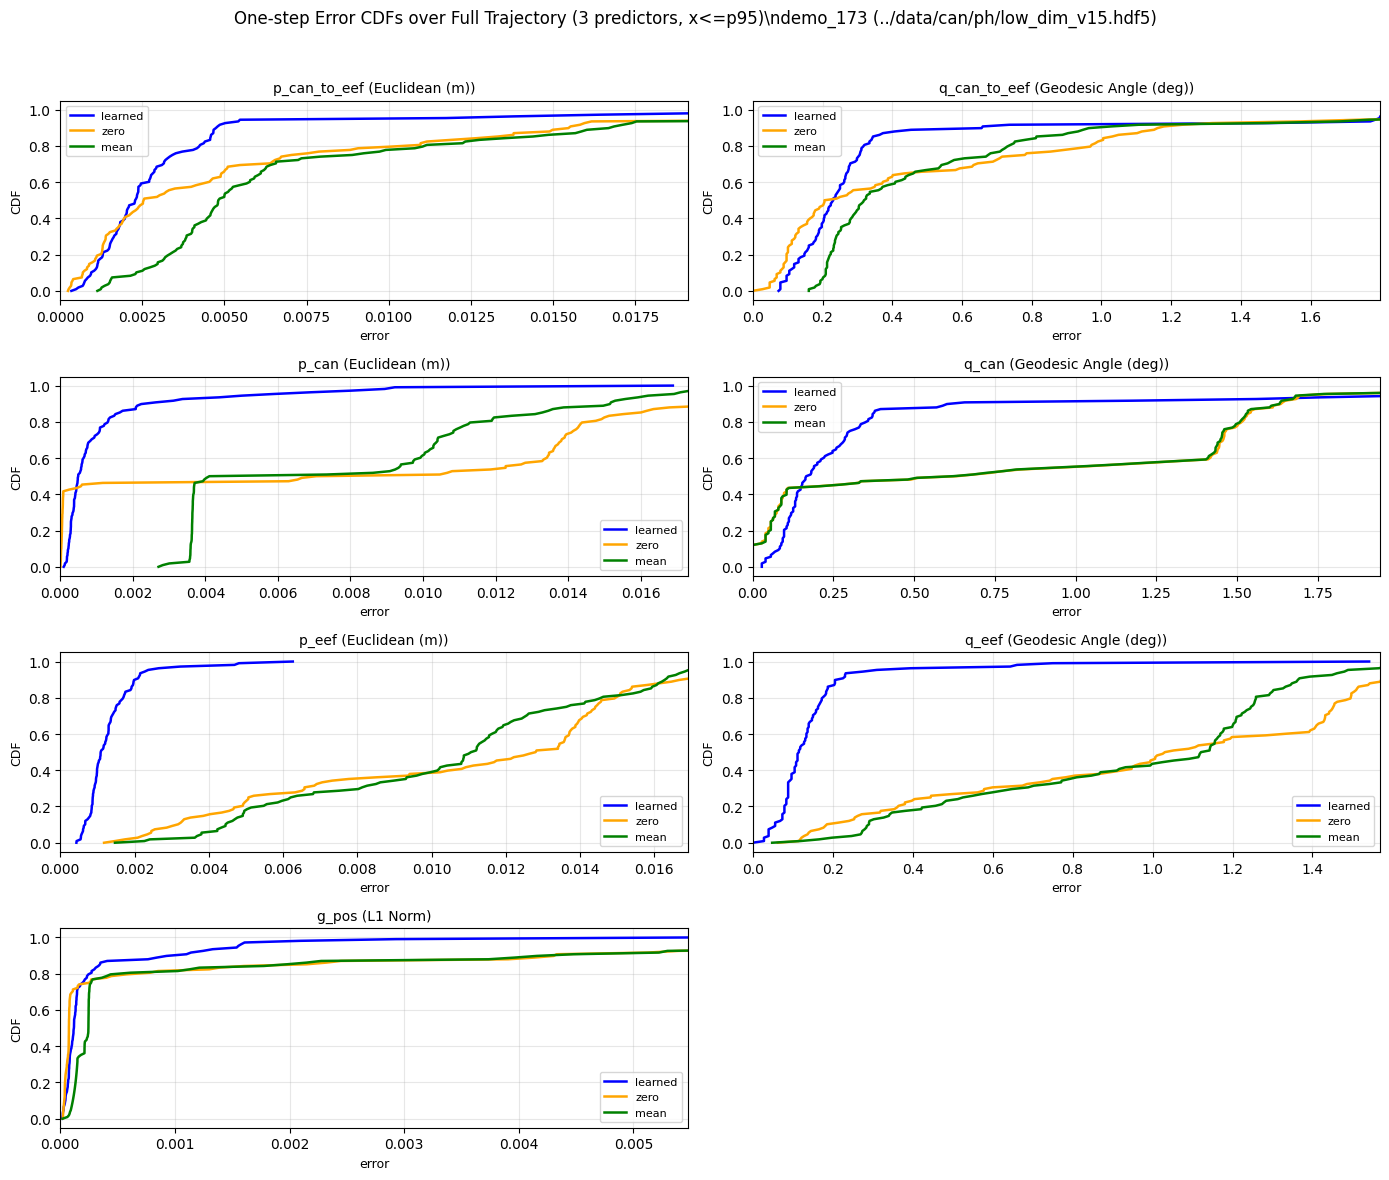


Summary: Median and p95 errors for one validation demo (n=109 transitions)

Component            Metric                                 Learned (med/p95)                 Mean (med/p95)                 Zero (med/p95)
------------------------------------------------------------------------------------------------------------------------
p_can_to_eef         Euclidean (m)                        0.002279 / 0.009234            0.004812 / 0.029702            0.002536 / 0.026712
q_can_to_eef         Geodesic Angle (deg)                 0.230700 / 1.792915            0.318981 / 1.877336            0.205584 / 1.876032
p_can                Euclidean (m)                        0.000494 / 0.005535            0.004110 / 0.016633            0.007058 / 0.019389
q_can                Geodesic Angle (deg)                 0.165511 / 2.019873            0.620551 / 1.733641            0.631801 / 1.744675
p_eef                Euclidean (m)                        0.001088 / 0.002331            0.011065 / 0.

In [41]:
# Evaluation of one full trajectory (reusable helpers + single-demo run)

metrics = {
    "p_can_to_eef": ("Euclidean (m)", euclidean_distance),
    "q_can_to_eef": ("Geodesic Angle (deg)", geodesic_rotation_error),
    "p_can": ("Euclidean (m)", euclidean_distance),
    "q_can": ("Geodesic Angle (deg)", geodesic_rotation_error),
    "p_eef": ("Euclidean (m)", euclidean_distance),
    "q_eef": ("Geodesic Angle (deg)", geodesic_rotation_error),
    "g_pos": ("L1 Norm", l1_norm),
}

ROT_KEYS = {"q_can_to_eef", "q_can", "q_eef"}


def evaluate_trajectory_errors(demo, predictors, stats, metrics, device):
    """
    Computes one-step per-timestep errors for one trajectory.

    Returns:
        dict:
            {
              "learned": {key: [errors...]},
              "zero": {key: [errors...]},
              "mean": {key: [errors...]},
            }
    """
    errors = {
        name: {k: [] for k in metrics}
        for name in predictors.keys()
    }

    T = demo["states"].shape[0]

    with torch.no_grad():
        for t in range(T):
            s_t_raw = demo["states"][t]
            a_t_raw = demo["actions"][t]
            s_next_true_raw = demo["next_states"][t]

            s_t_norm = (s_t_raw - stats["state_mean"]) / stats["state_std"]
            a_t_norm = (a_t_raw - stats["action_mean"]) / stats["action_std"]

            s_t_norm_t = torch.from_numpy(s_t_norm).float().unsqueeze(0).to(device)
            a_t_norm_t = torch.from_numpy(a_t_norm).float().unsqueeze(0).to(device)

            c_true = deconstruct_state(s_next_true_raw)

            for model_name, predictor in predictors.items():
                d_pred_n = predictor(s_t_norm_t, a_t_norm_t)[0].cpu().numpy()
                d_pred = d_pred_n * stats["delta_std"] + stats["delta_mean"]
                s_next_pred = s_t_raw + d_pred
                c_pred = deconstruct_state(s_next_pred)

                for key, (_, metric_fn) in metrics.items():
                    err = metric_fn(c_true[key], c_pred[key])
                    if key in ROT_KEYS:
                        err = np.degrees(err)
                    errors[model_name][key].append(float(err))

    return errors


def evaluate_demos_aggregated(demos, predictors, stats, metrics, device):
    """
    Aggregates one-step errors across all timesteps of all demos.
    """
    agg_errors = {
        name: {k: [] for k in metrics}
        for name in predictors.keys()
    }

    for demo in demos:
        demo_errors = evaluate_trajectory_errors(demo, predictors, stats, metrics, device)
        for model_name in predictors.keys():
            for key in metrics.keys():
                agg_errors[model_name][key].extend(demo_errors[model_name][key])

    return agg_errors


def plot_error_cdfs(errors, metrics, title, x_clip_percentile=None):
    """
    Plot CDFs for learned, zero, and mean predictors.

    Args:
        x_clip_percentile: if set (e.g., 95 or 99), clip each subplot x-axis
            to that percentile of pooled model errors for readability.
    """
    fig, axes = plt.subplots(4, 2, figsize=(14, 12))
    axes = axes.flatten()

    color_map = {"learned": "blue", "zero": "orange", "mean": "green"}
    ordered_models = ["learned", "zero", "mean"]

    for i, (key, (metric_name, _)) in enumerate(metrics.items()):
        ax = axes[i]

        series = {}
        for model_name in ordered_models:
            x = np.sort(np.asarray(errors[model_name][key], dtype=np.float32))
            y = np.linspace(0.0, 1.0, len(x), endpoint=True)
            ax.plot(x, y, label=model_name, linewidth=1.8, color=color_map[model_name])
            series[model_name] = x

        if x_clip_percentile is not None:
            pooled = np.concatenate([series[m] for m in ordered_models if len(series[m]) > 0])
            if pooled.size > 0:
                x_max = float(np.percentile(pooled, x_clip_percentile))
                # Keep a tiny positive range to avoid matplotlib warnings for degenerate axes.
                x_max = max(x_max, 1e-8)
                ax.set_xlim(0.0, x_max)

        ax.set_title(f"{key} ({metric_name})", fontsize=10)
        ax.set_xlabel("error", fontsize=9)
        ax.set_ylabel("CDF", fontsize=9)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[-1].axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def print_error_summary(errors, metrics, total_steps, header):
    """Print median and p95 summary for each component and model."""
    print("\n" + "=" * 120)
    print(f"{header} (n={total_steps} transitions)\n")
    print(f"{'Component':<20} {'Metric':<25} {'Learned (med/p95)':>30} {'Mean (med/p95)':>30} {'Zero (med/p95)':>30}")
    print("-" * 120)

    for key, (metric_name, _) in metrics.items():
        errs_l = np.asarray(errors["learned"][key], dtype=np.float32)
        errs_m = np.asarray(errors["mean"][key], dtype=np.float32)
        errs_z = np.asarray(errors["zero"][key], dtype=np.float32)

        med_l, p95_l = np.median(errs_l), np.percentile(errs_l, 95)
        med_m, p95_m = np.median(errs_m), np.percentile(errs_m, 95)
        med_z, p95_z = np.median(errs_z), np.percentile(errs_z, 95)

        learned_str = f"{med_l:.6f} / {p95_l:.6f}"
        mean_str = f"{med_m:.6f} / {p95_m:.6f}"
        zero_str = f"{med_z:.6f} / {p95_z:.6f}"

        print(f"{key:<20} {metric_name:<25} {learned_str:>30} {mean_str:>30} {zero_str:>30}")

    print("=" * 120)


predictors = {
    "learned": predictor_learned,
    "zero": predictor_zero,
    "mean": predictor_mean,
}

# Choose 95 or 99 depending on how aggressively you want to suppress tails.
# 99 is usually a good default for readability.
x_clip_percentile = 95

# Single-demo run (same as before, now via reusable helpers)
demo = val_trajectories[0]
T = demo["states"].shape[0]
print(f"Demo ID: {demo['demo_id']}")
print(f"Path: {demo['path']}")
print(f"Timesteps: {T}")

errors_demo = evaluate_trajectory_errors(demo, predictors, stats, metrics, device)

plot_error_cdfs(
    errors_demo,
    metrics,
    title=(
        f"One-step Error CDFs over Full Trajectory (3 predictors, x<=p{x_clip_percentile})\\n"
        f"{demo['demo_id']} ({demo['path']})"
    ),
    x_clip_percentile=x_clip_percentile,
)

print_error_summary(
    errors_demo,
    metrics,
    total_steps=T,
    header="Summary: Median and p95 errors for one validation demo",
)


Validation demos: 100
Total validation transitions: 17470


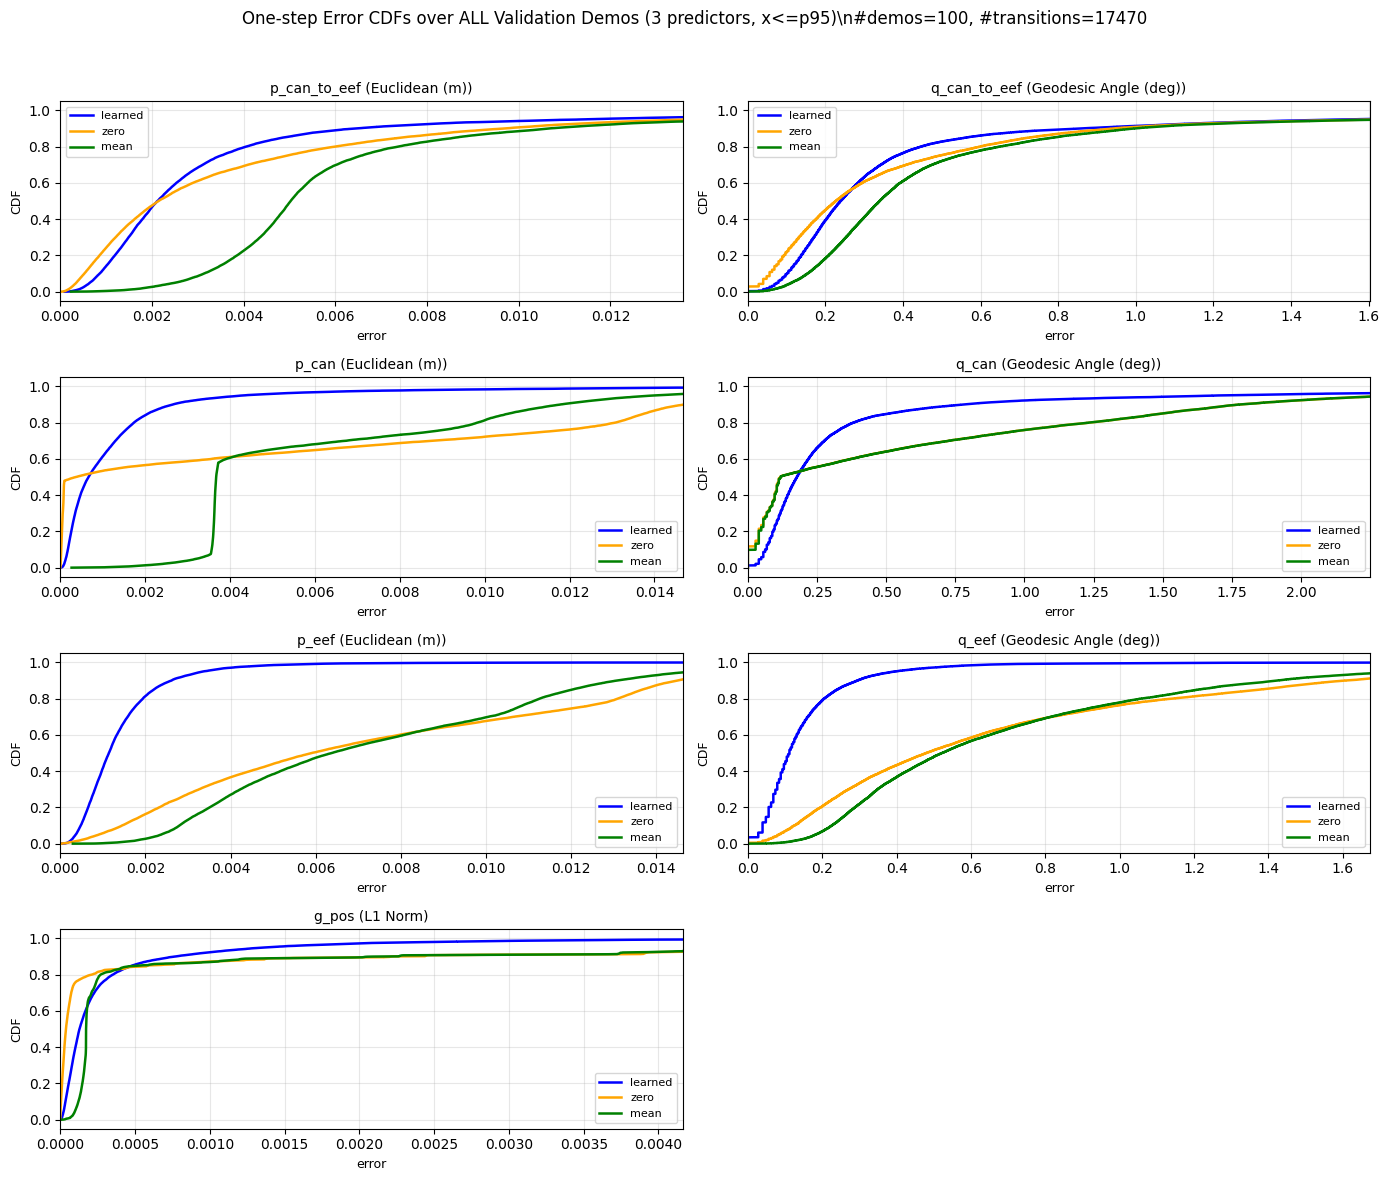


Summary: Median and p95 errors over ALL validation demos (n=17470 transitions)

Component            Metric                                 Learned (med/p95)                 Mean (med/p95)                 Zero (med/p95)
------------------------------------------------------------------------------------------------------------------------
p_can_to_eef         Euclidean (m)                        0.002119 / 0.011368            0.005025 / 0.015049            0.002143 / 0.013737
q_can_to_eef         Geodesic Angle (deg)                 0.239031 / 1.530155            0.340349 / 1.666854            0.227282 / 1.628299
p_can                Euclidean (m)                        0.000665 / 0.004300            0.003673 / 0.014000            0.000367 / 0.016573
q_can                Geodesic Angle (deg)                 0.176939 / 1.699802            0.118694 / 2.336539            0.118694 / 2.337343
p_eef                Euclidean (m)                        0.001141 / 0.003356            0.006375 

In [16]:
# ALL validation demos: aggregate per-step errors and plot CDFs

num_val_demos = len(val_trajectories)
num_val_steps = int(sum(tr["states"].shape[0] for tr in val_trajectories))

print(f"Validation demos: {num_val_demos}")
print(f"Total validation transitions: {num_val_steps}")

errors_val_all = evaluate_demos_aggregated(val_trajectories, predictors, stats, metrics, device)

plot_error_cdfs(
    errors_val_all,
    metrics,
    title=(
        f"One-step Error CDFs over ALL Validation Demos (3 predictors, x<=p{x_clip_percentile})\\n"
        f"#demos={num_val_demos}, #transitions={num_val_steps}"
    ),
    x_clip_percentile=x_clip_percentile,
)

print_error_summary(
    errors_val_all,
    metrics,
    total_steps=num_val_steps,
    header="Summary: Median and p95 errors over ALL validation demos",
)


#### Multi-Step Analysis

Demo ID: demo_173
Path: ../data/can/ph/low_dim_v15.hdf5
Window start_t: 70
Horizon: 8


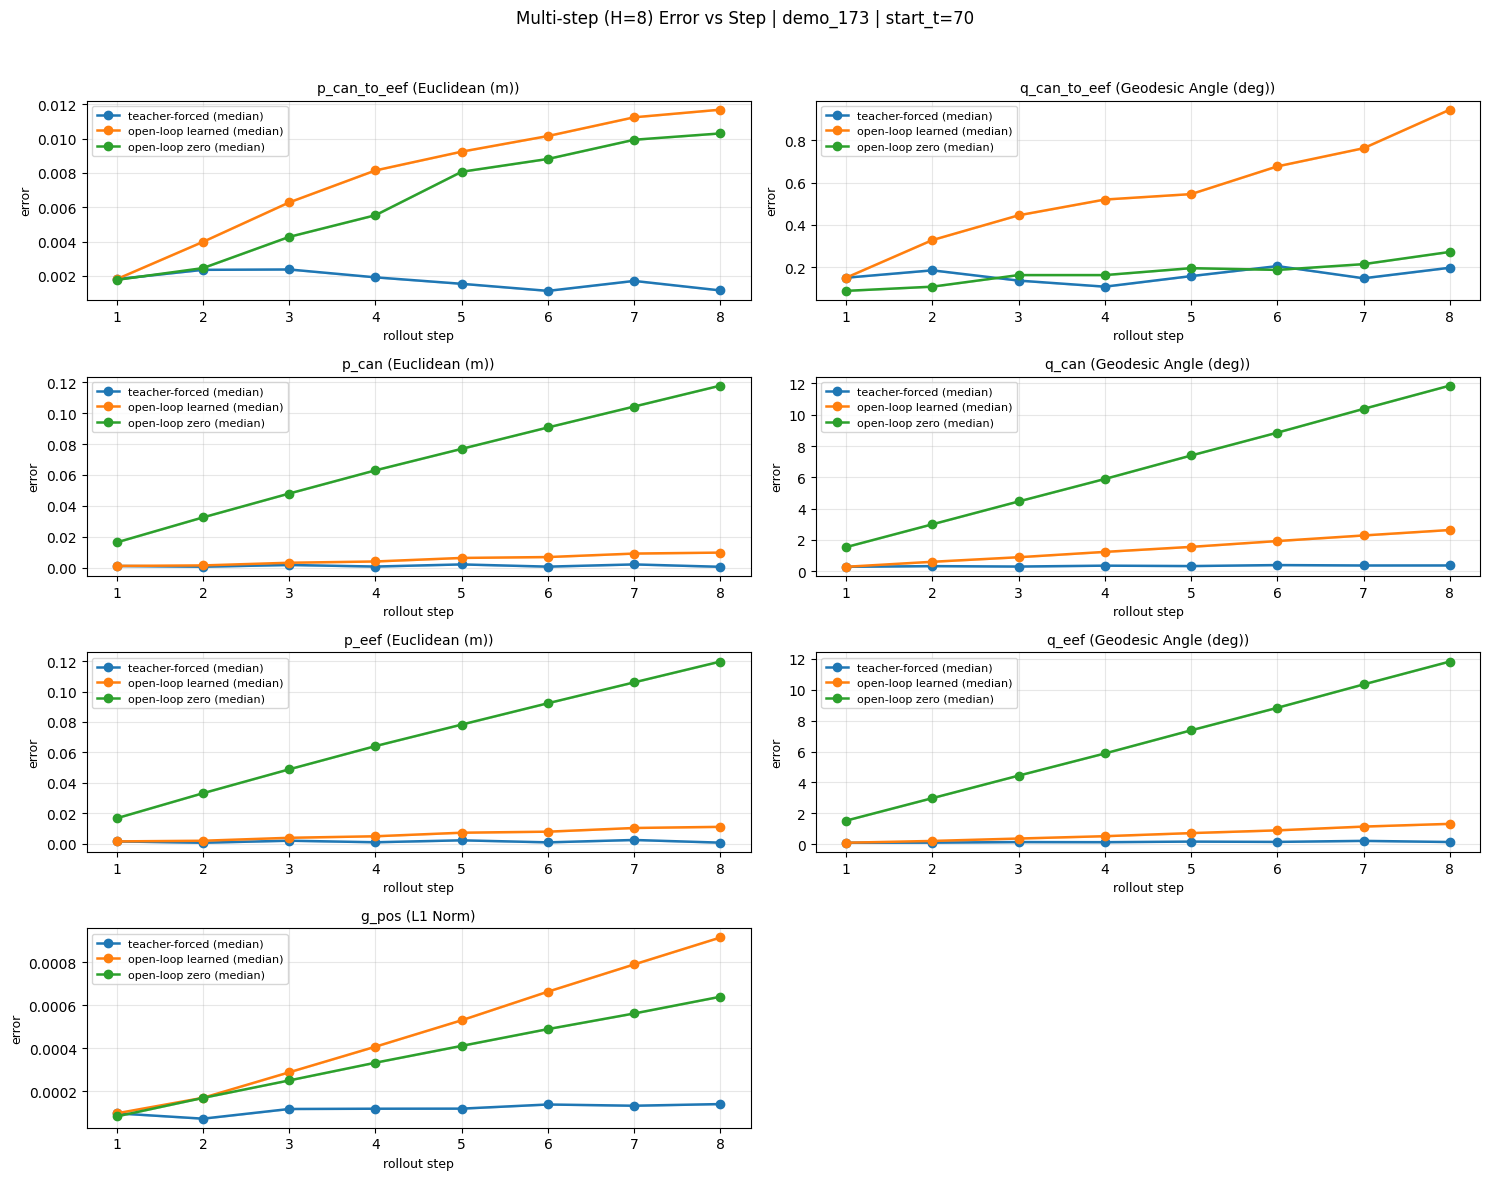


Final-step errors (step = horizon)
Component                  TF med   OL learned med    OL zero med     Learned/TF      Zero/TF
--------------------------------------------------------------------------------------------------------------------------------------------
p_can_to_eef             0.001153         0.011693       0.010308         10.145        8.943
q_can_to_eef             0.197824         0.945433       0.272681          4.779        1.378
p_can                    0.000540         0.009728       0.117801         18.015      218.138
q_can                    0.371150         2.636113      11.860429          7.103       31.956
p_eef                    0.000613         0.011008       0.119740         17.965      195.418
q_eef                    0.158259         1.330898      11.809476          8.410       74.621
g_pos                    0.000142         0.000916       0.000641          6.472        4.526


In [17]:
# First multi-step test: one held-out rollout window (teacher-forced vs open-loop)
# Reusable helpers are defined here and reused by later cells.


def predict_next_state_from_raw(s_t_raw, a_t_raw, predictor, stats, device):
    """One-step prediction in raw state space from raw (s_t, a_t)."""
    s_t_norm = (s_t_raw - stats["state_mean"]) / stats["state_std"]
    a_t_norm = (a_t_raw - stats["action_mean"]) / stats["action_std"]

    s_t_norm_t = torch.from_numpy(s_t_norm).float().unsqueeze(0).to(device)
    a_t_norm_t = torch.from_numpy(a_t_norm).float().unsqueeze(0).to(device)

    with torch.no_grad():
        d_pred_n = predictor(s_t_norm_t, a_t_norm_t)[0].cpu().numpy()

    d_pred = d_pred_n * stats["delta_std"] + stats["delta_mean"]
    return s_t_raw + d_pred


def init_multistep_error_store(metrics, horizon):
    """errors_by_mode[mode][key][k] = list of errors at rollout step k."""
    return {
        "teacher_forced": {k: [[] for _ in range(horizon)] for k in metrics},
        "open_loop_learned": {k: [[] for _ in range(horizon)] for k in metrics},
        "open_loop_zero": {k: [[] for _ in range(horizon)] for k in metrics},
    }


def append_window_errors(
    demo,
    start_t,
    horizon,
    predictor_learned,
    predictor_zero,
    stats,
    metrics,
    device,
    rot_keys,
    errors_by_mode,
):
    """Accumulate teacher-forced, learned open-loop, and zero open-loop errors for one window."""
    s_roll_learned = demo["states"][start_t].copy()
    s_roll_zero = demo["states"][start_t].copy()

    for k in range(horizon):
        idx = start_t + k

        s_true_t = demo["states"][idx]
        a_t = demo["actions"][idx]
        s_true_next = demo["next_states"][idx]

        s_tf_next = predict_next_state_from_raw(s_true_t, a_t, predictor_learned, stats, device)
        s_ol_learned_next = predict_next_state_from_raw(s_roll_learned, a_t, predictor_learned, stats, device)
        s_ol_zero_next = predict_next_state_from_raw(s_roll_zero, a_t, predictor_zero, stats, device)

        c_true_next = deconstruct_state(s_true_next)
        c_tf_next = deconstruct_state(s_tf_next)
        c_ol_learned_next = deconstruct_state(s_ol_learned_next)
        c_ol_zero_next = deconstruct_state(s_ol_zero_next)

        for key, (_, metric_fn) in metrics.items():
            e_tf = metric_fn(c_true_next[key], c_tf_next[key])
            e_ol_learned = metric_fn(c_true_next[key], c_ol_learned_next[key])
            e_ol_zero = metric_fn(c_true_next[key], c_ol_zero_next[key])

            if key in rot_keys:
                e_tf = np.degrees(e_tf)
                e_ol_learned = np.degrees(e_ol_learned)
                e_ol_zero = np.degrees(e_ol_zero)

            errors_by_mode["teacher_forced"][key][k].append(float(e_tf))
            errors_by_mode["open_loop_learned"][key][k].append(float(e_ol_learned))
            errors_by_mode["open_loop_zero"][key][k].append(float(e_ol_zero))

        s_roll_learned = s_ol_learned_next
        s_roll_zero = s_ol_zero_next


def aggregate_multistep_errors_across_demos(
    demos,
    horizon,
    predictor_learned,
    predictor_zero,
    stats,
    metrics,
    device,
    rot_keys,
    show_progress=True,
):
    """Aggregate multi-step errors over all valid windows from all demos."""
    errors_by_mode = init_multistep_error_store(metrics, horizon)

    total_windows = 0
    iter_demos = tqdm(demos, desc="Aggregating demos") if show_progress else demos

    for demo in iter_demos:
        t_demo = demo["states"].shape[0]
        num_windows = t_demo - horizon + 1
        if num_windows <= 0:
            continue

        total_windows += num_windows
        for start_t in range(num_windows):
            append_window_errors(
                demo=demo,
                start_t=start_t,
                horizon=horizon,
                predictor_learned=predictor_learned,
                predictor_zero=predictor_zero,
                stats=stats,
                metrics=metrics,
                device=device,
                rot_keys=rot_keys,
                errors_by_mode=errors_by_mode,
            )

    return errors_by_mode, total_windows


def compute_step_stats(step_lists, q_low=10, q_high=90):
    """Convert per-step error lists to median/low/high arrays."""
    med = []
    low = []
    high = []
    for vals in step_lists:
        arr = np.asarray(vals, dtype=np.float32)
        med.append(float(np.median(arr)))
        low.append(float(np.percentile(arr, q_low)))
        high.append(float(np.percentile(arr, q_high)))
    return np.asarray(med), np.asarray(low), np.asarray(high)


def plot_median_band(ax, steps, step_lists, label, color, q_low, q_high):
    med, low, high = compute_step_stats(step_lists, q_low=q_low, q_high=q_high)
    ax.plot(steps, med, marker="o", linewidth=1.8, color=color, label=label)
    ax.fill_between(steps, low, high, color=color, alpha=0.18)


def plot_multistep_summary(
    errors_by_mode,
    metrics,
    horizon,
    title,
    band_low_q=25,
    band_high_q=75,
    y_clip_percentile=None,
    y_clip_multiplier=2.0,
):
    """Plot per-component rollout-step medians + quantile bands for all modes."""
    steps = np.arange(1, horizon + 1)
    fig, axes = plt.subplots(4, 2, figsize=(15, 12))
    axes = axes.flatten()

    for i, (key, (metric_name, _)) in enumerate(metrics.items()):
        ax = axes[i]

        plot_median_band(
            ax,
            steps,
            errors_by_mode["teacher_forced"][key],
            label="teacher-forced (median)",
            color="tab:blue",
            q_low=band_low_q,
            q_high=band_high_q,
        )
        plot_median_band(
            ax,
            steps,
            errors_by_mode["open_loop_learned"][key],
            label="open-loop learned (median)",
            color="tab:orange",
            q_low=band_low_q,
            q_high=band_high_q,
        )
        plot_median_band(
            ax,
            steps,
            errors_by_mode["open_loop_zero"][key],
            label="open-loop zero (median)",
            color="tab:green",
            q_low=band_low_q,
            q_high=band_high_q,
        )

        if y_clip_percentile is not None:
            learned_all = np.asarray(
                [e for step_vals in errors_by_mode["open_loop_learned"][key] for e in step_vals],
                dtype=np.float32,
            )
            if learned_all.size > 0:
                y_max = y_clip_multiplier * float(np.percentile(learned_all, y_clip_percentile))
                y_max = max(y_max, 1e-8)
                ax.set_ylim(0.0, y_max)

        ax.set_title(f"{key} ({metric_name})", fontsize=10)
        ax.set_xlabel("rollout step", fontsize=9)
        ax.set_ylabel("error", fontsize=9)
        ax.set_xticks(steps)
        ax.grid(alpha=0.3)
        ax.legend(fontsize=8)

    axes[-1].axis("off")
    plt.suptitle(title, fontsize=12)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


def print_multistep_final_step_summary(
    errors_by_mode,
    metrics,
    band_low_q=25,
    band_high_q=75,
    header="Final-step aggregated errors",
):
    """Print compact summary at final rollout step based on median curves."""
    print(f"\n{header}")
    print("=" * 140)
    print(f"{'Component':<20} {'TF med':>12} {'OL learned med':>16} {'OL zero med':>14} {'Learned/TF':>14} {'Zero/TF':>12}")
    print("-" * 140)

    for key in metrics.keys():
        tf_med, _, _ = compute_step_stats(errors_by_mode["teacher_forced"][key], q_low=band_low_q, q_high=band_high_q)
        l_med, _, _ = compute_step_stats(errors_by_mode["open_loop_learned"][key], q_low=band_low_q, q_high=band_high_q)
        z_med, _, _ = compute_step_stats(errors_by_mode["open_loop_zero"][key], q_low=band_low_q, q_high=band_high_q)

        final_tf = tf_med[-1]
        final_l = l_med[-1]
        final_z = z_med[-1]

        ratio_l = final_l / max(final_tf, 1e-8)
        ratio_z = final_z / max(final_tf, 1e-8)

        print(f"{key:<20} {final_tf:>12.6f} {final_l:>16.6f} {final_z:>14.6f} {ratio_l:>14.3f} {ratio_z:>12.3f}")

    print("=" * 140)


# -------------------------------
# Run: single held-out window
# -------------------------------
demo = val_trajectories[0]
start_t = 70
horizon = 8

T_demo = demo["states"].shape[0]
if start_t < 0 or start_t + horizon > T_demo:
    raise ValueError(
        f"Invalid window: start_t={start_t}, horizon={horizon}, demo_len={T_demo}. "
        "Need start_t + horizon <= demo_len."
    )

print(f"Demo ID: {demo['demo_id']}")
print(f"Path: {demo['path']}")
print(f"Window start_t: {start_t}")
print(f"Horizon: {horizon}")

errors_single = init_multistep_error_store(metrics, horizon)
append_window_errors(
    demo=demo,
    start_t=start_t,
    horizon=horizon,
    predictor_learned=predictor_learned,
    predictor_zero=predictor_zero,
    stats=stats,
    metrics=metrics,
    device=device,
    rot_keys=ROT_KEYS,
    errors_by_mode=errors_single,
)

# For a single window, q25=q75 reproduces line-only behavior (one value per step).
plot_multistep_summary(
    errors_by_mode=errors_single,
    metrics=metrics,
    horizon=horizon,
    title=f"Multi-step (H={horizon}) Error vs Step | {demo['demo_id']} | start_t={start_t}",
    band_low_q=50,
    band_high_q=50,
    y_clip_percentile=None,
)

print_multistep_final_step_summary(
    errors_by_mode=errors_single,
    metrics=metrics,
    band_low_q=50,
    band_high_q=50,
    header="Final-step errors (step = horizon)",
)


Demo ID: demo_173
Path: ../data/can/ph/low_dim_v15.hdf5
Trajectory length: 109
Horizon: 16
Valid windows: 94 (start_t = 0..93)
Band: p25 to p75


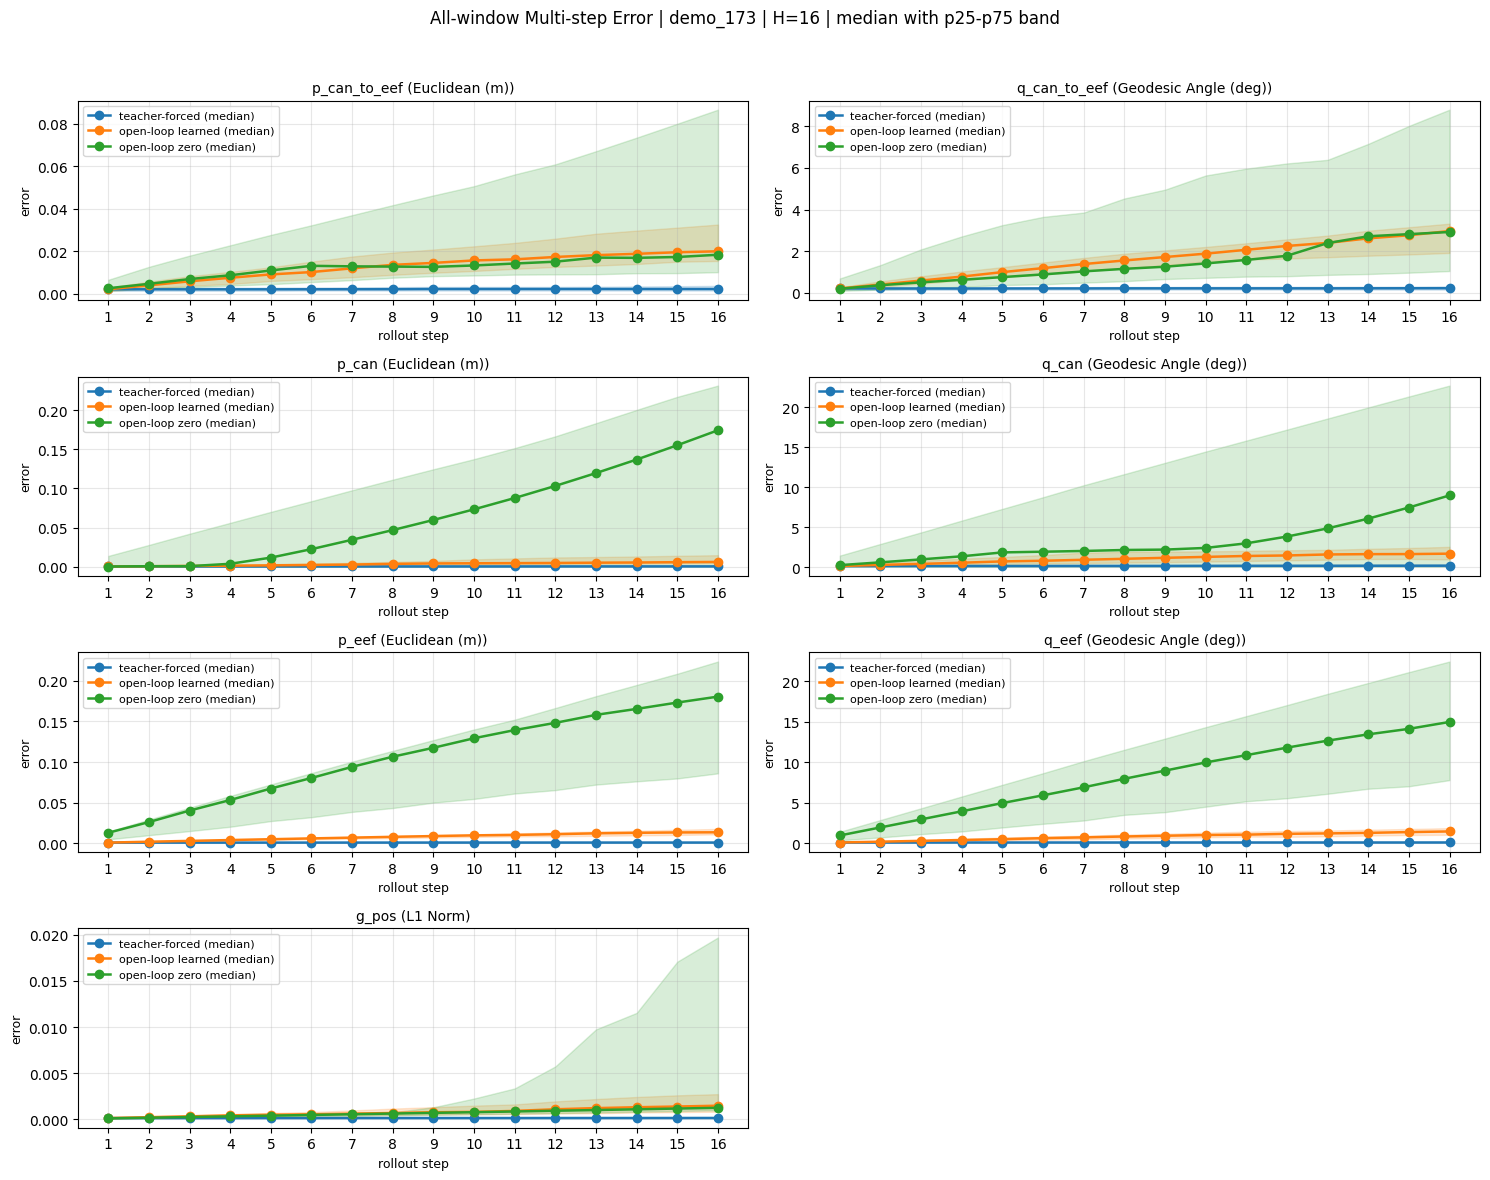


Final-step aggregated errors over all windows
Component                  TF med   OL learned med    OL zero med     Learned/TF      Zero/TF
--------------------------------------------------------------------------------------------------------------------------------------------
p_can_to_eef             0.002177         0.019943       0.018315          9.159        8.412
q_can_to_eef             0.228991         2.969264       2.922420         12.967       12.762
p_can                    0.000588         0.006244       0.174260         10.625      296.536
q_can                    0.194769         1.698440       8.987198          8.720       46.143
p_eef                    0.001086         0.013690       0.180460         12.602      166.111
q_eef                    0.115300         1.476699      14.981519         12.807      129.935
g_pos                    0.000119         0.001452       0.001220         12.179       10.231


In [18]:
# Multi-window rollout aggregation on one trajectory (using Cell 26 helpers)

# Configuration
demo = val_trajectories[0]
horizon = 16
band_low_q = 25
band_high_q = 75

T_demo = demo["states"].shape[0]
num_windows = T_demo - horizon + 1
if num_windows <= 0:
    raise ValueError(
        f"Trajectory too short: len={T_demo}, horizon={horizon}. Need len >= horizon."
    )

print(f"Demo ID: {demo['demo_id']}")
print(f"Path: {demo['path']}")
print(f"Trajectory length: {T_demo}")
print(f"Horizon: {horizon}")
print(f"Valid windows: {num_windows} (start_t = 0..{num_windows - 1})")
print(f"Band: p{band_low_q} to p{band_high_q}")

errors_demo_windows, total_windows_demo = aggregate_multistep_errors_across_demos(
    demos=[demo],
    horizon=horizon,
    predictor_learned=predictor_learned,
    predictor_zero=predictor_zero,
    stats=stats,
    metrics=metrics,
    device=device,
    rot_keys=ROT_KEYS,
    show_progress=False,
)

plot_multistep_summary(
    errors_by_mode=errors_demo_windows,
    metrics=metrics,
    horizon=horizon,
    title=(
        f"All-window Multi-step Error | {demo['demo_id']} | H={horizon} | "
        f"median with p{band_low_q}-p{band_high_q} band"
    ),
    band_low_q=band_low_q,
    band_high_q=band_high_q,
    y_clip_percentile=None,
)

print_multistep_final_step_summary(
    errors_by_mode=errors_demo_windows,
    metrics=metrics,
    band_low_q=band_low_q,
    band_high_q=band_high_q,
    header="Final-step aggregated errors over all windows",
)


In [ ]:
# All held-out trajectories (using Cell 26 helpers)

# Configuration
horizon = 16
band_low_q = 25
band_high_q = 75
y_clip_percentile = 95
y_clip_multiplier = 2.0

errors_all_heldout, total_windows_all = aggregate_multistep_errors_across_demos(
    demos=val_trajectories,
    horizon=horizon,
    predictor_learned=predictor_learned,
    predictor_zero=predictor_zero,
    stats=stats,
    metrics=metrics,
    device=device,
    rot_keys=ROT_KEYS,
    show_progress=True,
)

print(f"Held-out demos: {len(val_trajectories)}")
print(f"Total valid windows across held-out demos: {total_windows_all}")
print(f"Horizon: {horizon}")
print(f"Band: p{band_low_q}-p{band_high_q}")
print(f"Y clip: {y_clip_multiplier} x p{y_clip_percentile} of learned open-loop")

plot_multistep_summary(
    errors_by_mode=errors_all_heldout,
    metrics=metrics,
    horizon=horizon,
    title=(
        f"All Held-out Demos Multi-step Error | #demos={len(val_trajectories)} | "
        f"#windows={total_windows_all} | H={horizon}"
    ),
    band_low_q=band_low_q,
    band_high_q=band_high_q,
    y_clip_percentile=y_clip_percentile,
    y_clip_multiplier=y_clip_multiplier,
)

print_multistep_final_step_summary(
    errors_by_mode=errors_all_heldout,
    metrics=metrics,
    band_low_q=band_low_q,
    band_high_q=band_high_q,
)


## Online Evaluation (Testing the Model in Env)

In [ ]:
# Preparing Policy and Environmnet for 'Real World' Testing

CKPT_PATH = "../models/can/model_epoch_2000.pth"

# --- Load checkpoint dict (robomimic-style)
ckpt = torch.load(CKPT_PATH, map_location="cpu")
cfg = ckpt["config"]
cfg = json.loads(cfg)
cfg["observation"]["modalities"]
from robomimic.utils.file_utils import maybe_dict_from_checkpoint

# Replace with your actual model path
ckpt_dict = maybe_dict_from_checkpoint(CKPT_PATH)

# This will tell us the exact input dimension the policy network sees

# Important: init obs modalities exactly as training expected
ObsUtils.initialize_obs_utils_with_obs_specs(cfg["observation"]["modalities"])

env, _ = FileUtils.env_from_checkpoint(
    ckpt_path=CKPT_PATH,
    render=True,
    render_offscreen=True,
)
# env = frameenv.env
    # policy.start_episode()
policy, _ = FileUtils.policy_from_checkpoint(
    ckpt_path=CKPT_PATH,
    device=device,
    verbose=True,
)

ObservationKeyToModalityDict: robot0_joint_pos not found, adding robot0_joint_pos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_cos not found, adding robot0_joint_pos_cos to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_pos_sin not found, adding robot0_joint_pos_sin to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_joint_vel not found, adding robot0_joint_vel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_eef_quat_site not found, adding robot0_eef_quat_site to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: robot0_gripper_qvel not found, adding robot0_gripper_qvel to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: lang_emb not found, adding lang_emb to mapping with assumed low_dim modality!
ObservationKeyToModalityDict: timesteps not found, adding timesteps to mapping with assumed low_dim modality!
Observat

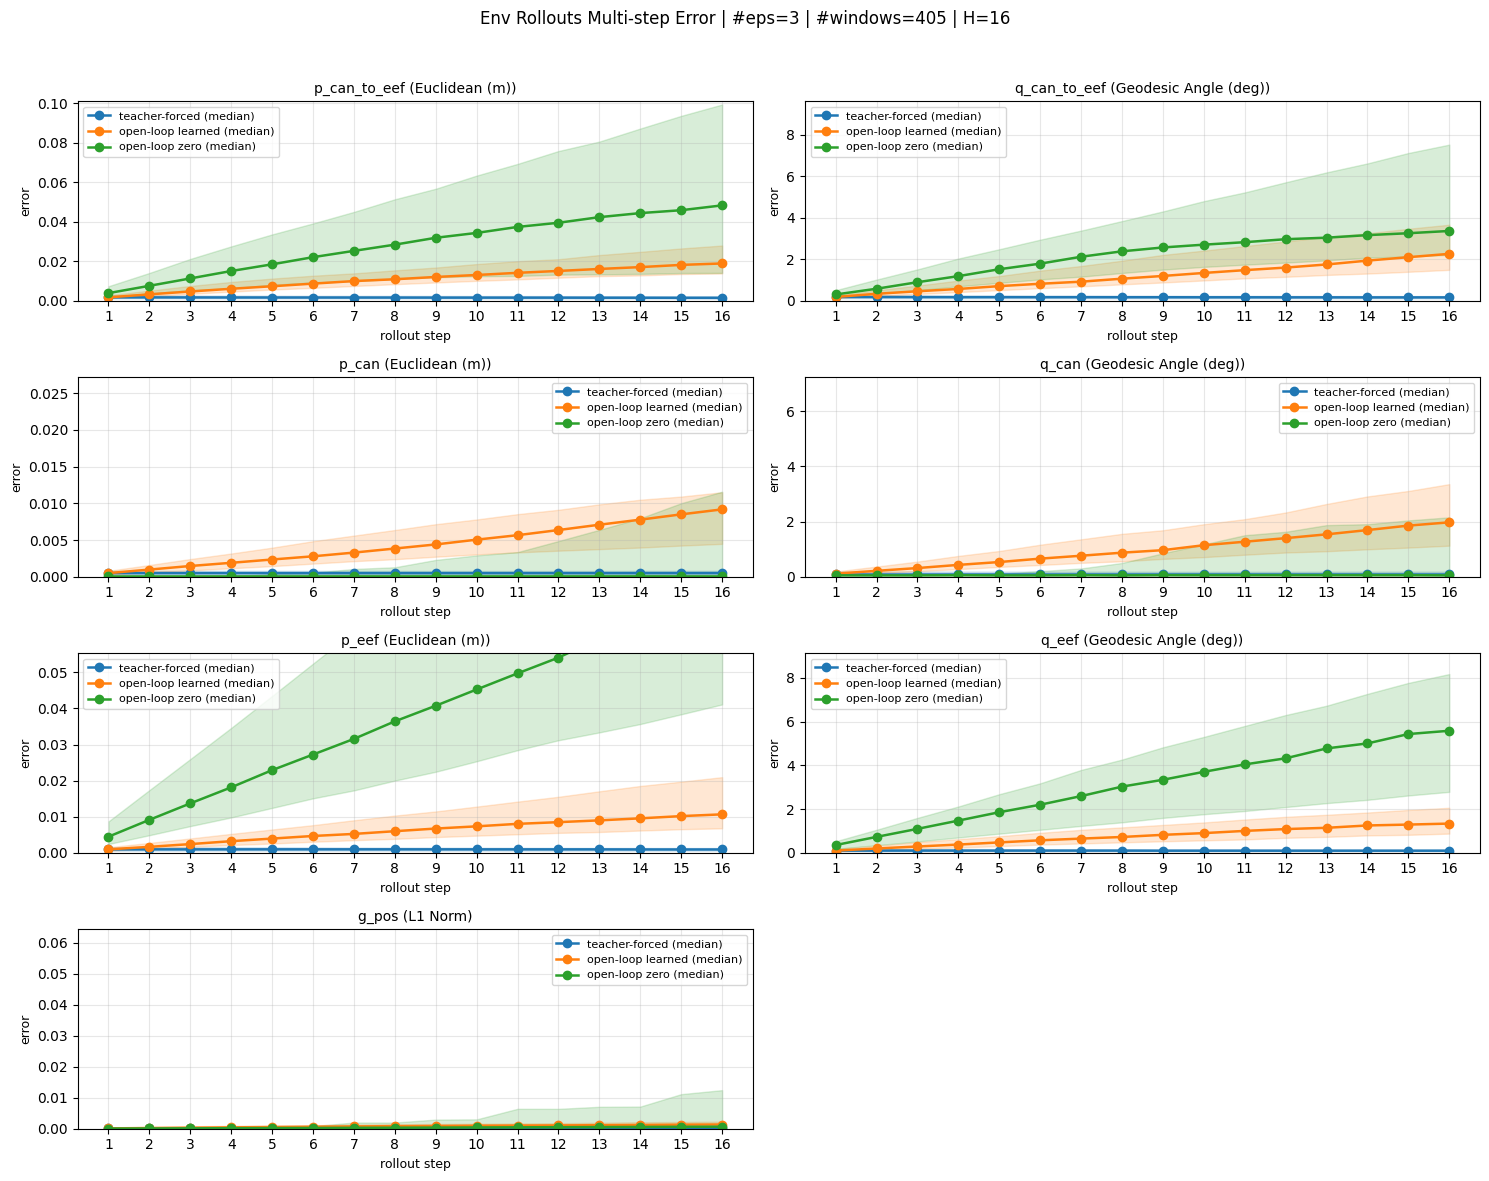


Final-step env multi-step aggregated errors
Component                  TF med   OL learned med    OL zero med     Learned/TF      Zero/TF
--------------------------------------------------------------------------------------------------------------------------------------------
p_can_to_eef             0.001488         0.018876       0.048300         12.690       32.470
q_can_to_eef             0.160713         2.261918       3.367204         14.074       20.952
p_can                    0.000493         0.009171       0.000040         18.621        0.082
q_can                    0.111906         1.970601       0.048457         17.609        0.433
p_eef                    0.000898         0.010638       0.072324         11.841       80.502
q_eef                    0.092787         1.332955       5.580053         14.366       60.138
g_pos                    0.000091         0.001359       0.000655         14.952        7.206


In [19]:
# Real env sanity-test before any DP gradient integration
# 1) Roll out current policy in env
# 2) Build env trajectories in the same 29D state format
# 3) Evaluate one-step and multi-step (H<=16) world-model error on env data

# Settings (keep small for quick iteration; scale up once stable)
num_env_rollouts = 3
max_env_steps = 150
horizon_env = 16
band_low_q = 25
band_high_q = 75
y_clip_percentile = 95
y_clip_multiplier = 2.0


# Reuse existing helper if already defined; otherwise define a fallback.
if "build_state_from_obs_dict" not in globals():
    def _latest_1d(x):
        x = np.asarray(x)
        if x.ndim <= 1:
            return x
        return x[-1]

    def build_state_from_obs_dict(obs_dict):
        obj = _latest_1d(obs_dict["object"])
        p_can_to_eef = obj[0:3]
        q_can_to_eef = quat_to_6d(xyzw_to_wxyz_batch(obj[3:7][None]))[0]
        p_can = obj[7:10]
        q_can = quat_to_6d(xyzw_to_wxyz_batch(obj[10:14][None]))[0]
        p_eef = _latest_1d(obs_dict["robot0_eef_pos"])
        q_eef = quat_to_6d(xyzw_to_wxyz_batch(_latest_1d(obs_dict["robot0_eef_quat"])[None]))[0]
        g_pos = _latest_1d(obs_dict["robot0_gripper_qpos"])
        if g_pos.size == 0:
            g_pos = np.zeros(2, dtype=np.float32)
        return np.concatenate([p_can_to_eef, q_can_to_eef, p_can, q_can, p_eef, q_eef, g_pos], axis=-1).astype(np.float32)


def policy_action(obs_dict):
    """Policy call wrapper for robomimic RolloutPolicy."""
    action = policy(obs_dict)
    action = np.asarray(action, dtype=np.float32)
    return action


def collect_env_rollout_trajectories(env, policy, num_rollouts=3, max_steps=150):
    """Collect trajectories in the same structure used by offline evaluation."""
    trajectories_env = []

    for ep in range(num_rollouts):
        obs = env.reset()
        policy.start_episode()

        states = []
        actions = []
        next_states = []
        rewards = []

        for t in range(max_steps):
            s_t = build_state_from_obs_dict(obs)
            a_t = policy_action(obs)

            obs_next, r, done, _ = env.step(a_t)
            s_next = build_state_from_obs_dict(obs_next)

            states.append(s_t)
            actions.append(a_t)
            next_states.append(s_next)
            rewards.append(float(r))

            obs = obs_next
            if done:
                break

        if len(actions) == 0:
            continue

        states = np.asarray(states, dtype=np.float32)
        actions = np.asarray(actions, dtype=np.float32)
        next_states = np.asarray(next_states, dtype=np.float32)
        deltas = (next_states - states).astype(np.float32)

        trajectories_env.append({
            "path": "env_rollout",
            "demo_id": f"env_ep_{ep}",
            "states": states,
            "actions": actions,
            "next_states": next_states,
            "deltas": deltas,
            "episode_return": float(np.sum(rewards)),
            "episode_len": int(len(actions)),
        })

    return trajectories_env


def evaluate_one_step_on_env_demos(demos, predictor_learned, predictor_zero, stats, metrics, device):
    """One-step error summary on env-collected transitions."""
    predictors_env = {
        "learned": predictor_learned,
        "zero": predictor_zero,
    }

    errors = {
        name: {k: [] for k in metrics}
        for name in predictors_env.keys()
    }

    for demo in demos:
        T_demo = demo["states"].shape[0]
        with torch.no_grad():
            for t in range(T_demo):
                s_t_raw = demo["states"][t]
                a_t_raw = demo["actions"][t]
                s_next_true_raw = demo["next_states"][t]

                c_true = deconstruct_state(s_next_true_raw)

                for model_name, predictor_eval in predictors_env.items():
                    s_next_pred = predict_next_state_from_raw(s_t_raw, a_t_raw, predictor_eval, stats, device)
                    c_pred = deconstruct_state(s_next_pred)

                    for key, (_, metric_fn) in metrics.items():
                        err = metric_fn(c_true[key], c_pred[key])
                        if key in ROT_KEYS:
                            err = np.degrees(err)
                        errors[model_name][key].append(float(err))

    return errors


# ---- Run collection ----
env_trajectories = collect_env_rollout_trajectories(
    env=env,
    policy=policy,
    num_rollouts=num_env_rollouts,
    max_steps=max_env_steps,
)

num_env_eps = len(env_trajectories)
num_env_transitions = int(sum(tr["states"].shape[0] for tr in env_trajectories))

print(f"Collected env rollouts: {num_env_eps}")
print(f"Collected env transitions: {num_env_transitions}")
if num_env_eps > 0:
    mean_ret = np.mean([tr["episode_return"] for tr in env_trajectories])
    mean_len = np.mean([tr["episode_len"] for tr in env_trajectories])
    print(f"Mean return: {mean_ret:.4f}")
    print(f"Mean episode length: {mean_len:.1f}")


# ---- One-step sanity check on env data ----
if num_env_transitions > 0:
    errors_env_one_step = evaluate_one_step_on_env_demos(
        demos=env_trajectories,
        predictor_learned=predictor_learned,
        predictor_zero=predictor_zero,
        stats=stats,
        metrics=metrics,
        device=device,
    )

    print("\nOne-step env summary (learned vs zero):")
    print("=" * 110)
    print(f"{'Component':<20} {'Learned med/p95':>24} {'Zero med/p95':>24}")
    print("-" * 110)
    for key in metrics.keys():
        e_l = np.asarray(errors_env_one_step["learned"][key], dtype=np.float32)
        e_z = np.asarray(errors_env_one_step["zero"][key], dtype=np.float32)

        l_med, l_p95 = float(np.median(e_l)), float(np.percentile(e_l, 95))
        z_med, z_p95 = float(np.median(e_z)), float(np.percentile(e_z, 95))

        print(f"{key:<20} {f'{l_med:.6f} / {l_p95:.6f}':>24} {f'{z_med:.6f} / {z_p95:.6f}':>24}")
    print("=" * 110)


# ---- Multi-step env aggregation (same pipeline as offline) ----
if num_env_transitions > 0:
    errors_env_multistep, total_windows_env = aggregate_multistep_errors_across_demos(
        demos=env_trajectories,
        horizon=horizon_env,
        predictor_learned=predictor_learned,
        predictor_zero=predictor_zero,
        stats=stats,
        metrics=metrics,
        device=device,
        rot_keys=ROT_KEYS,
        show_progress=False,
    )

    print(f"\nEnv multi-step windows: {total_windows_env}")
    print(f"Horizon: {horizon_env}")

    if total_windows_env > 0:
        plot_multistep_summary(
            errors_by_mode=errors_env_multistep,
            metrics=metrics,
            horizon=horizon_env,
            title=(
                f"Env Rollouts Multi-step Error | #eps={num_env_eps} | "
                f"#windows={total_windows_env} | H={horizon_env}"
            ),
            band_low_q=band_low_q,
            band_high_q=band_high_q,
            y_clip_percentile=y_clip_percentile,
            y_clip_multiplier=y_clip_multiplier,
        )

        print_multistep_final_step_summary(
            errors_by_mode=errors_env_multistep,
            metrics=metrics,
            band_low_q=band_low_q,
            band_high_q=band_high_q,
            header="Final-step env multi-step aggregated errors",
        )
    else:
        print("No valid env windows for the requested horizon. Increase rollout length or reduce horizon.")


In [74]:
# Single rollout of policy for Rzz analysis (obs-29D vs MuJoCo state)
horizon = 500
branch_horizon = 8
branch_stride = 8
video_skip = 1
camera_name = "frontview"
world_model_dir = "../models/dynamics/baseline_mlp"
rollout_dir = os.path.join(world_model_dir, "test_rollouts")
os.makedirs(rollout_dir, exist_ok=True)
video_path = os.path.join(rollout_dir, f"rollout_h{horizon}_{camera_name}.mp4")
mujoco_body_name = "Can_main"

def get_metrics(env, body_name="Can_main"):
    probe = env
    sim = None
    for _ in range(8):
        if hasattr(probe, "sim"):
            sim = probe.sim
            break
        if not hasattr(probe, "env"):
            break
        probe = probe.env
    if sim is None:
        raise RuntimeError("Could not locate MuJoCo sim on wrapped env.")
    bid = sim.model.body_name2id(body_name)
    rzz = float(sim.data.body_xmat[bid].reshape(3, 3)[2, 2])
    pos = sim.data.body_xpos[bid].copy()
    return rzz, pos

# Reset flow (matching rollout reference pattern)
policy.start_episode()
obs = env.reset()
state0 = env.get_state()
obs = env.reset_to(state0)

# Trajectory containers
states = [build_state_from_obs_dict(obs)]
actions = []
rewards = []
rzz_mujoco = []
can_pos_mujoco = []

rzz0, pos0 = get_metrics(env, body_name=mujoco_body_name)
rzz_mujoco.append(rzz0)
can_pos_mujoco.append(pos0)

video_writer = imageio.get_writer(video_path, fps=20)
total_reward = 0.0
success = False
steps_executed = 0

try:
    for step_i in range(horizon):
        act = policy(obs)
        next_obs, r, done, _ = env.step(act)
        actions.append(np.asarray(act, dtype=np.float32))
        rewards.append(float(r))
        states.append(build_state_from_obs_dict(next_obs))

        rzz_now, pos_now = get_metrics(env, body_name=mujoco_body_name)
        rzz_mujoco.append(rzz_now)
        can_pos_mujoco.append(pos_now)

        total_reward += float(r)
        steps_executed = step_i + 1

        if step_i % video_skip == 0:
            frame = env.render(mode="rgb_array", height=512, width=512, camera_name=camera_name)
            video_writer.append_data(frame)

        is_success = env.is_success()
        success = bool(is_success["task"]) if isinstance(is_success, dict) and "task" in is_success else bool(is_success)
        if done or success:
            break
        obs = next_obs
finally:
    video_writer.close()

print(f"Rollout video saved: {video_path}")
print(f"Horizon: {horizon}")
print(f"Executed steps: {steps_executed}")
print(f"Return: {total_reward:.4f}")
print(f"Success: {success}")
print(f"Rzz samples (MuJoCo): {len(rzz_mujoco)} | State samples: {len(states)}")

Rollout video saved: ../models/dynamics/baseline_mlp/test_rollouts/rollout_h500_frontview.mp4
Horizon: 500
Executed steps: 209
Return: 1.0000
Success: True
Rzz samples (MuJoCo): 210 | State samples: 210


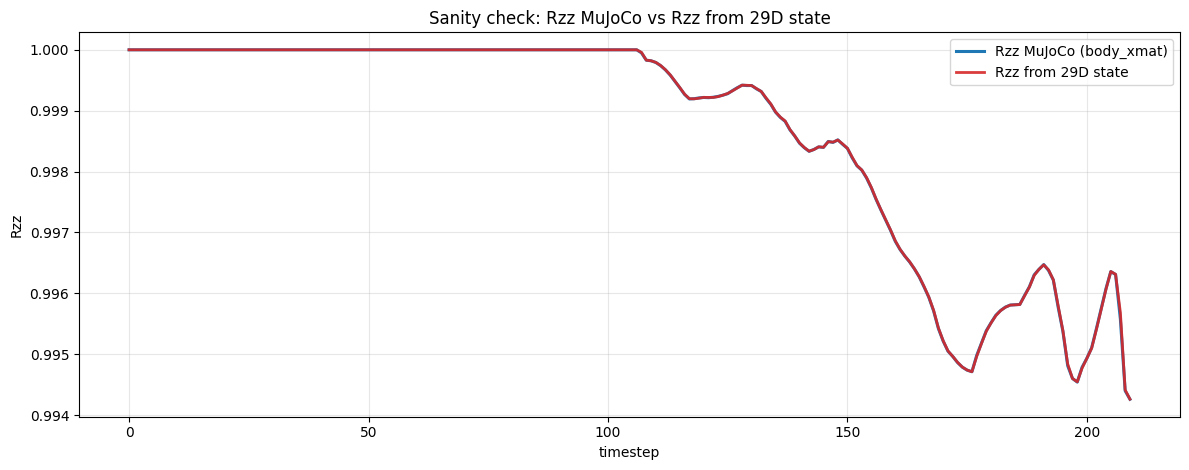

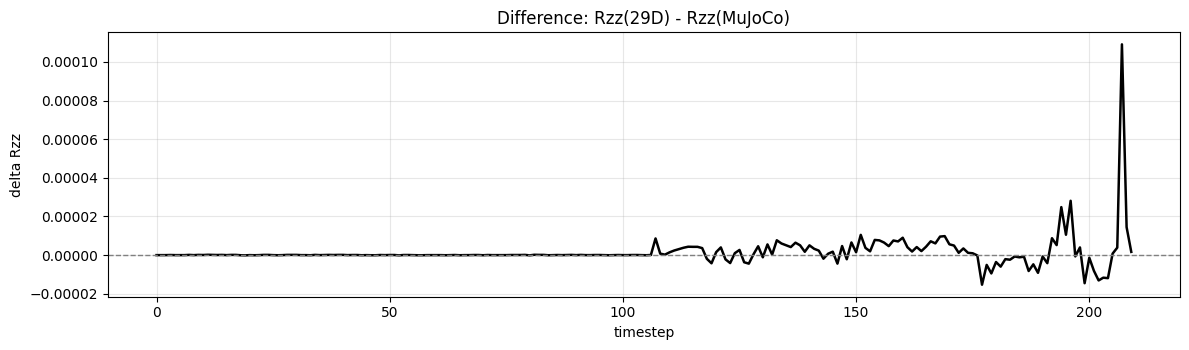

Rzz abs diff | mean: 3.021672e-06, max: 1.091361e-04


'../models/dynamics/baseline_mlp/test_rollouts/rollout_h500_frontview.mp4'

In [ ]:
# Sanity check: compare Rzz from MuJoCo sim to Rzz from 29D state reconstruction

# Rzz helper from 29D state
def rzz_from_state_29d(state_29d):
    q_can_6d = deconstruct_state(state_29d)["q_can"]
    R_can = reconstruct_rotation_matrix_from_6d(q_can_6d)
    return float(R_can[2, 2])

# Build both Rzz vectors: obs-pipeline (29D state) and MuJoCo body pose
rzz_obs_29d = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
rzz_mujoco_arr = np.asarray(rzz_mujoco, dtype=np.float32)

# Align lengths defensively
n = min(len(rzz_obs_29d), len(rzz_mujoco_arr))
if n == 0:
    raise ValueError("No rollout samples available for Rzz comparison.")
if n != len(rzz_obs_29d) or n != len(rzz_mujoco_arr):
    print(f"Length mismatch detected. Using first {n} samples for comparison.")
rzz_obs_29d = rzz_obs_29d[:n]
rzz_mujoco_arr = rzz_mujoco_arr[:n]
t = np.arange(n)

# Plot 1: MuJoCo vs 29D-state Rzz
fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(t, rzz_mujoco_arr, color="#1f77b4", linewidth=2.2, label="Rzz MuJoCo (body_xmat)")
ax.plot(t, rzz_obs_29d, color="#d62728", linewidth=2.0, alpha=0.9, label="Rzz from 29D state")
ax.set_title("Sanity check: Rzz MuJoCo vs Rzz from 29D state")
ax.set_xlabel("timestep")
ax.set_ylabel("Rzz")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Plot 2: residual for drift inspection
rzz_diff = rzz_obs_29d - rzz_mujoco_arr
fig, ax = plt.subplots(figsize=(12, 3.6))
ax.plot(t, rzz_diff, color="black", linewidth=1.8)
ax.axhline(0.0, color="gray", linewidth=1.0, linestyle="--")
ax.set_title("Difference: Rzz(29D) - Rzz(MuJoCo)")
ax.set_xlabel("timestep")
ax.set_ylabel("delta Rzz")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Rzz abs diff | mean: {np.mean(np.abs(rzz_diff)):.6e}, max: {np.max(np.abs(rzz_diff)):.6e}")
video_path

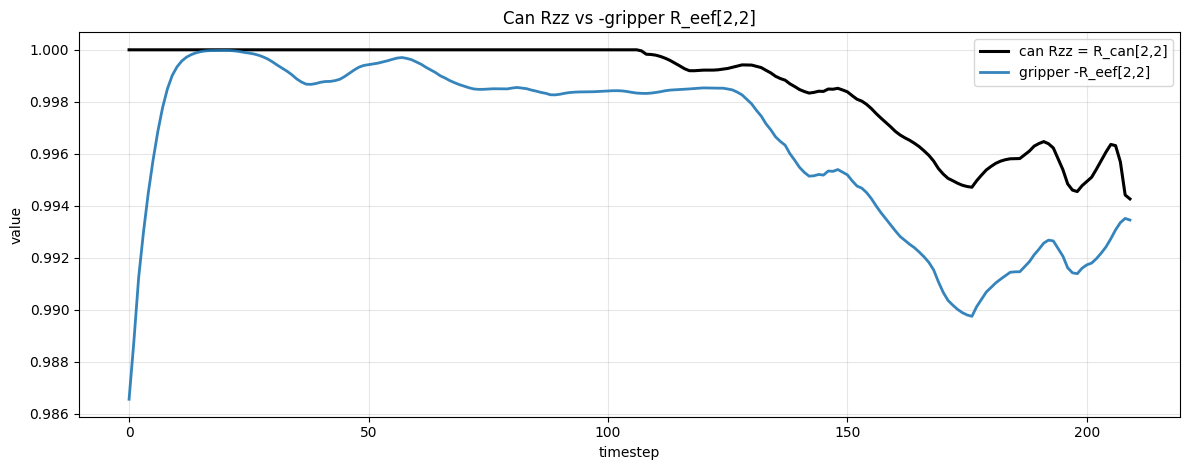

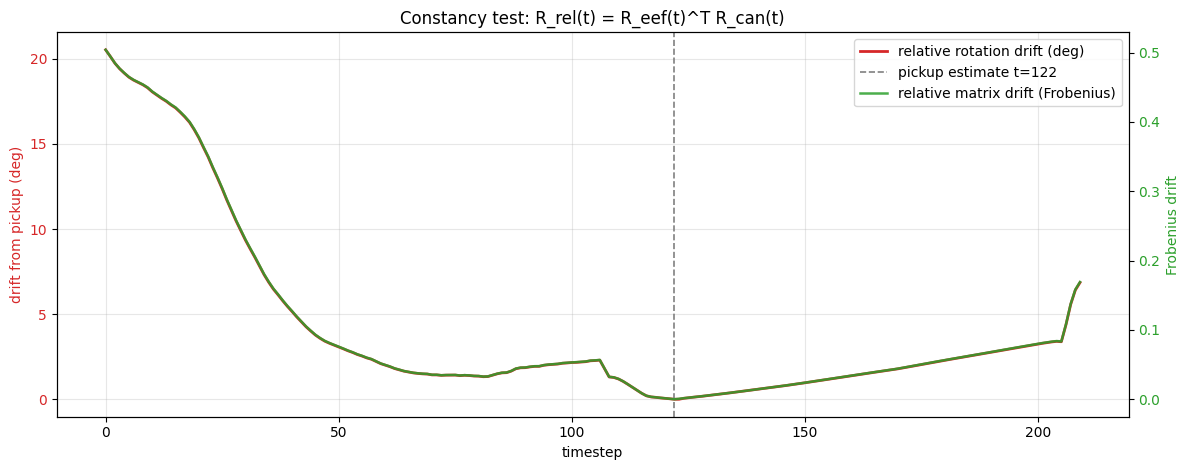

pickup index used: 122
post-pick relative drift (deg) | mean=1.792486, max=6.856437


In [82]:
# Dynamics complexity check: does the can rigidly follow gripper orientation after pickup?

def can_rotmat_from_state(state_29d):
    q_can_6d = deconstruct_state(state_29d)["q_can"]
    return reconstruct_rotation_matrix_from_6d(q_can_6d)

def eef_rotmat_from_state(state_29d):
    q_eef_6d = deconstruct_state(state_29d)["q_eef"]
    return reconstruct_rotation_matrix_from_6d(q_eef_6d)

# Build rotation traces from 29D state stream
R_can_all = np.asarray([can_rotmat_from_state(s) for s in states], dtype=np.float32)
R_eef_all = np.asarray([eef_rotmat_from_state(s) for s in states], dtype=np.float32)

n = min(R_can_all.shape[0], R_eef_all.shape[0])
if n == 0:
    raise ValueError("No state samples available for can/eef orientation comparison.")

R_can_all = R_can_all[:n]
R_eef_all = R_eef_all[:n]
t = np.arange(n)

# Plot 1: direct scalar comparison requested previously
can_rzz = R_can_all[:, 2, 2]
neg_eef_rzz = -R_eef_all[:, 2, 2]

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.plot(t, can_rzz, color="black", linewidth=2.2, label="can Rzz = R_can[2,2]")
ax.plot(t, neg_eef_rzz, color="#1f77b4", linewidth=2.0, alpha=0.9, label="gripper -R_eef[2,2]")
ax.set_title("Can Rzz vs -gripper R_eef[2,2]")
ax.set_xlabel("timestep")
ax.set_ylabel("value")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

# Relative rotation metric: should be constant if can is rigidly aligned with gripper
# R_rel maps gripper frame to can frame at each timestep.
R_rel_all = np.matmul(np.transpose(R_eef_all, (0, 2, 1)), R_can_all)

# Heuristic pickup detection from MuJoCo can height if available; fallback to t=0.
t_pick = 0
if "can_pos_mujoco" in globals() and len(can_pos_mujoco) >= n:
    can_pos_arr = np.asarray(can_pos_mujoco[:n], dtype=np.float32)
    z = can_pos_arr[:, 2]
    lift_thresh_m = 0.005
    lift_idx = np.where((z - z[0]) > lift_thresh_m)[0]
    if lift_idx.size > 0:
        t_pick = int(lift_idx[0])

R_rel_ref = R_rel_all[t_pick]

# Geodesic drift from pickup-relative orientation (degrees).
rel_drift_deg = np.zeros(n, dtype=np.float32)
for k in range(n):
    R_delta = R_rel_ref.T @ R_rel_all[k]
    cos_theta = (np.trace(R_delta) - 1.0) / 2.0
    cos_theta = np.clip(cos_theta, -1.0, 1.0)
    rel_drift_deg[k] = np.degrees(np.arccos(cos_theta))

# Secondary matrix drift metric (Frobenius norm).
rel_drift_fro = np.linalg.norm(R_rel_all - R_rel_ref[None, :, :], axis=(1, 2))

fig, ax1 = plt.subplots(figsize=(12, 4.8))
ax1.plot(t, rel_drift_deg, color="#d62728", linewidth=2.0, label="relative rotation drift (deg)")
ax1.axvline(t_pick, color="gray", linestyle="--", linewidth=1.2, label=f"pickup estimate t={t_pick}")
ax1.set_title("Constancy test: R_rel(t) = R_eef(t)^T R_can(t)")
ax1.set_xlabel("timestep")
ax1.set_ylabel("drift from pickup (deg)", color="#d62728")
ax1.tick_params(axis="y", labelcolor="#d62728")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(t, rel_drift_fro, color="#2ca02c", linewidth=1.8, alpha=0.85, label="relative matrix drift (Frobenius)")
ax2.set_ylabel("Frobenius drift", color="#2ca02c")
ax2.tick_params(axis="y", labelcolor="#2ca02c")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="upper right")
plt.tight_layout()
plt.show()

if t_pick < n - 1:
    post = rel_drift_deg[t_pick:]
    print(f"pickup index used: {t_pick}")
    print(f"post-pick relative drift (deg) | mean={np.mean(post):.6f}, max={np.max(post):.6f}")
else:
    print(f"pickup index used: {t_pick} (last sample, no post-pick window)")

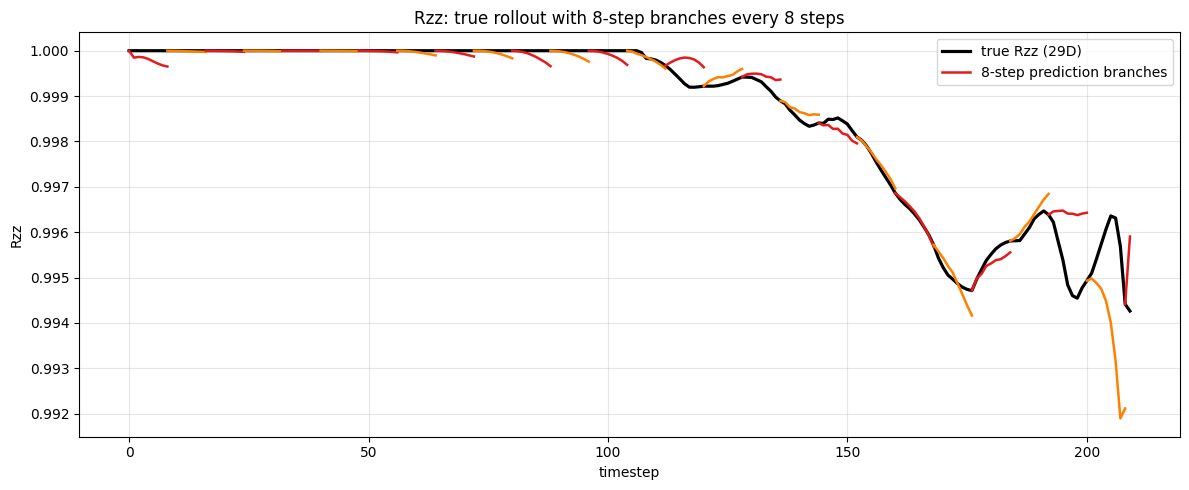

'../models/dynamics/baseline_mlp/test_rollouts/rollout_h500_frontview.mp4'

In [76]:
# Restored: 8-step branch plot (every 8 steps) on top of true Rzz from 29D state
if "rzz_from_state_29d" not in globals():
    def rzz_from_state_29d(state_29d):
        q_can_6d = deconstruct_state(state_29d)["q_can"]
        R_can = reconstruct_rotation_matrix_from_6d(q_can_6d)
        return float(R_can[2, 2])

true_rzz_29d = np.asarray([rzz_from_state_29d(s) for s in states], dtype=np.float32)
T_actions = len(actions)
branch_h = int(globals().get("branch_horizon", 8))
branch_s = int(globals().get("branch_stride", 8))
branch_colors = ["#e41a1c", "#ff7f00"]

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(np.arange(len(true_rzz_29d)), true_rzz_29d, color="black", linewidth=2.3, label="true Rzz (29D)", zorder=2)

first_branch = True
for branch_idx, t0 in enumerate(range(0, T_actions, branch_s)):
    s_roll = np.asarray(states[t0], dtype=np.float32).copy()
    branch_rzz = [true_rzz_29d[t0]]
    k_max = min(branch_h, T_actions - t0)

    for k in range(k_max):
        a_k = actions[t0 + k]
        s_roll = predict_next_state_from_raw(s_roll, a_k, predictor_learned, stats, device)
        branch_rzz.append(rzz_from_state_29d(s_roll))

    x_branch = np.arange(t0, t0 + len(branch_rzz))
    color = branch_colors[branch_idx % len(branch_colors)]
    ax.plot(
        x_branch,
        np.asarray(branch_rzz, dtype=np.float32),
        color=color,
        linewidth=1.8,
        alpha=1.0,
        label="8-step prediction branches" if first_branch else None,
        zorder=4,
    )
    first_branch = False

ax.set_title("Rzz: true rollout with 8-step branches every 8 steps")
ax.set_xlabel("timestep")
ax.set_ylabel("Rzz")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()
video_path